# 08 · Did the loyalty rollout work? — difference-in-differences (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** We launched the loyalty app in some stores, not others. Revenue in the
launch stores went up — but revenue went up *everywhere* (a seasonal tide lifts all boats). Did the app
add anything **net of that tide**, and is it worth rolling out to the whole chain?

### The idea: two differences

**Difference-in-differences (DiD)** is the workhorse of quasi-experiments. It takes **two** differences
and subtracts them:

$$\text{DiD} = \underbrace{(\bar Y^{\text{treated}}_{\text{after}} - \bar Y^{\text{treated}}_{\text{before}})}_{\text{treated change}} - \underbrace{(\bar Y^{\text{control}}_{\text{after}} - \bar Y^{\text{control}}_{\text{before}})}_{\text{control change}}.$$

The first difference (treated after − before) contains the app effect **plus** the seasonal tide; the
second (control after − before) is the tide **alone**. Subtracting removes the tide and leaves the app
effect. It's the same "compare like with like" logic as everywhere else, applied *across time*.

### The one assumption everything rests on: parallel trends

DiD is valid only if, **absent the app**, treated and control stores would have moved *in parallel* — the
control's change is a fair stand-in for what the treated stores' change would have been. This is untestable
after launch (we never see the treated stores' no-app future), but the **pre-launch trends are the
evidence**: if the two groups moved together *before* the app, parallel trends is credible. We check this
with an **event study** (the effect period-by-period) and falsify with a **placebo** (a fake
launch date in the pre-period, which should show ≈ 0 effect).

> **On real data.** Swap in your **own store/region panel** — one row per store per period with revenue, a
> treated/control flag, and a period index. The textbook public example is **Card & Krueger (1994)** on
> minimum wage and employment (fast-food restaurants in New Jersey vs Pennsylvania). One warning we
> *demonstrate live* in Step 7: if stores adopt at **different times** ("staggered rollout"), naive DiD can
> be badly biased and you need modern estimators (Callaway–Sant'Anna, Sun–Abraham).

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 23; LAUNCH = 12; TRUE = 400.0

## 2 · Simulate a ground truth

40 stores, half get the loyalty app at week 12. Every store shares a seasonal pattern and has its
own baseline; the app adds a **true €400/store/week**. Treated and control move in **parallel**
before launch by construction — so DiD should recover €400, and the event study should show a flat
pre-trend.

**The data-generating model** — exactly what `dgp.did_rollout` implements (defaults & seed in
`src/cmp/dgp.py`). Stores $s = 1,\dots,40$ (a random half treated, $D_s = 1$), weeks
$t = 0,\dots,23$, launch at week 12:

$$
Y_{st} = \underbrace{\alpha_s}_{\text{store baseline}}
  + \underbrace{60\sin\!\big(\tfrac{2\pi t}{12}\big)}_{\text{shared season}}
  + \underbrace{400\; D_s\, \mathbf 1[t \ge 12]}_{\text{true effect}}
  + \varepsilon_{st},
\qquad \alpha_s \sim \mathcal N(1000,\, 150^{2}),\;\;
\varepsilon_{st} \sim \mathcal N(0,\, 80^{2}).
$$

**Parallel trends holds by construction**: the seasonal term is *identical* across stores (no
store-specific loading on it) and $\alpha_s$ is time-invariant, so absent the app the treated and
control means move in lockstep — exactly what the event study's flat pre-trend should (and does)
show. This is the assumption the caveats section then breaks on purpose (staggered adoption) to
demonstrate the two-way fixed-effects (TWFE) trap.


In [2]:
df, true_effect = dgp.did_rollout(n_stores=40, n_weeks=24, launch_week=LAUNCH, true_effect=TRUE, seed=SEED)
print(f"TRUE effect = €{true_effect:.0f}/store/week  ·  {df['unit'].nunique()} stores, {df['t'].nunique()} weeks, launch week {LAUNCH}")
df.head()

TRUE effect = €400/store/week  ·  40 stores, 24 weeks, launch week 12


,store,unit,t,week,group,post_treatment,post,revenue
0,store_00,0,0,0,1,False,0,1071.613014
1,store_00,0,1,1,1,False,0,1066.597066
2,store_00,0,2,2,1,False,0,1019.187212
3,store_00,0,3,3,1,False,0,834.246887
4,store_00,0,4,4,1,False,0,1030.278745


## 3 · Identify — the estimand, and the two assumptions that buy it

**The estimand, precisely** — the *estimand* is the exact quantity we are trying to estimate. Store $s$ in week $t$ has two *potential* revenues: $Y_{st}(1)$ with the
app and $Y_{st}(0)$ without — we only ever observe one of them. With $D_s \in \{0,1\}$ flagging the
pilot stores and $t_0$ the launch week, DiD targets the **ATT**, the average treatment effect *on the
treated stores, after launch*:

$$\text{ATT} \;=\; \mathbb{E}\big[\,Y_{st}(1)-Y_{st}(0)\;\big|\;D_s=1,\ t\ge t_0\big].$$

The second term inside is the counterfactual we never see — what the pilot stores *would have* earned
post-launch without the app. Note the final **T**: this is the effect *on the pilot stores*, not on the
whole chain; it need not equal what the other stores would experience (pilot sites are rarely picked at
random), which is exactly why Step 6 stress-tests the transfer before scaling to 500 stores. Two named
assumptions let the control stores stand in for the missing counterfactual:

**Assumption 1 — Parallel trends (PT)**, stated on *untreated* potential outcomes: for any post-launch
week $t$ and pre-launch week $t'$,

$$\mathbb{E}\big[Y_{st}(0)-Y_{st'}(0)\,\big|\,D_s{=}1\big] \;=\; \mathbb{E}\big[Y_{st}(0)-Y_{st'}(0)\,\big|\,D_s{=}0\big],\qquad t\ge t_0 > t'.$$

In words: had the app never launched, the pilot stores' revenue would have *changed* by the same amount
as the controls'. **Levels may differ freely** — pilot stores can be systematically bigger, busier,
richer; it is the *changes* that must match. In marketing terms: the seasonal tide, chain-wide
promotions and macro shocks hit both groups alike, and nothing *time-varying and group-specific* (a
regional campaign running only in pilot cities, say) is in play.

**Assumption 2 — No anticipation (NA):**

$$\mathbb{E}\big[\,Y_{st}(1)-Y_{st}(0)\;\big|\;D_s=1\big] \;=\; 0 \qquad \text{for all } t<t_0,$$

i.e. the app moves nothing before it exists. Sounds vacuous; isn't. Pre-launch buzz marketing, staff
trained weeks early, or customers *deferring* purchases until the app's perks arrive all violate it —
and they contaminate the very "before" baseline that DiD subtracts. Step 7 breaks this assumption on
purpose so you can see what the damage looks like.

**Why DiD = ATT — the one-line derivation.** Take the treated group's observed before→after change and
split it, using NA (the treated pre-period observation *is* $Y(0)$), into effect plus counterfactual
trend (throughout, superscript $1$ = the treated/pilot group mean, $0$ = the control group mean):

$$\bar Y^{1}_{\text{post}}-\bar Y^{1}_{\text{pre}} \;=\; \underbrace{\text{ATT}}_{\text{what we want}} \;+\; \underbrace{\mathbb{E}\big[Y_{st}(0)-Y_{st'}(0)\,\big|\,D_s{=}1\big]}_{\text{counterfactual trend}}.$$

PT says that trend equals the *control* group's observed change $\bar Y^{0}_{\text{post}}-\bar
Y^{0}_{\text{pre}}$. Subtract it:

$$\text{DiD} \;=\; \big(\bar Y^{1}_{\text{post}}-\bar Y^{1}_{\text{pre}}\big)-\big(\bar Y^{0}_{\text{post}}-\bar Y^{0}_{\text{pre}}\big) \;=\; \text{ATT}.$$

That is the entire method: two assumptions in, one subtraction out.

**The regression forms you'll meet.** The **2×2 DiD** (two groups — pilot vs control — by two periods — pre vs post) is the interaction coefficient $\beta_3$ in
$Y=\beta_0+\beta_1\,\text{group}+\beta_2\,\text{post}+\beta_3\,(\text{group}\times\text{post})+\varepsilon$
— the version we fit in Step 4. Its dynamic cousin, the **event-study regression**, estimates one
effect per week relative to launch:

$$Y_{st}\;=\;\alpha_s+\lambda_t+\sum_{k\neq -1}\beta_k\,\mathbf 1[t-t_0=k]\,D_s+\varepsilon_{st},$$

with store fixed effects $\alpha_s$, common week effects $\lambda_t$, normalized at $k=-1$ — i.e. we peg the last pre-launch week to zero and read every other week's effect *relative to it* (one week must be dropped as the reference, or the store and week effects would be collinear with the full set of $\beta_k$). That is why the plot's dot at $k=-1$ sits exactly on zero and every other dot is a gap *from* it. The
nonparametric per-week treated−control gap we plot below *is* this regression's $\beta_k$ in the
balanced two-group case — same picture, so you can map our plot onto any paper's event study. The
**leads** ($k<0$) test NA directly and make PT *credible*; nothing can test PT itself post-launch (we
never observe the treated stores' no-app future).

**What the DAG buys us.** Contrast with notebook 01: backdoor adjustment needs the confounder
*measured* so you can condition on it. DiD strikes a different bargain — the store-level confounder
$\alpha_s$ (location, size, clientele: whatever drives both "chosen as pilot" *and* revenue) may stay
**unobserved**, provided it is *time-invariant*: differencing each group against its own past removes
$\alpha_s$, and subtracting the control change removes the common shocks $\lambda_t$. What survives
both subtractions is precisely what PT rules out: time-varying, group-specific shocks.

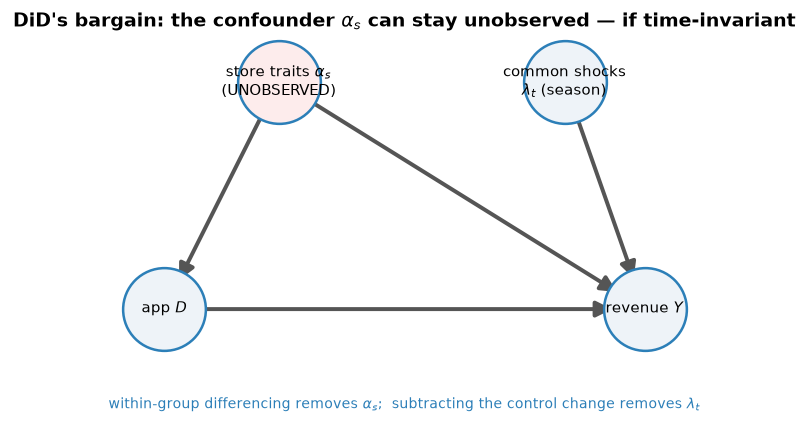

In [3]:
fig, ax = plt.subplots(figsize=(6.0, 3.4))
n_alpha = "store traits $\\alpha_s$\n(UNOBSERVED)"
n_lam   = "common shocks\n$\\lambda_t$ (season)"
n_d, n_y = "app $D$", "revenue $Y$"
pos = {n_alpha: (0.28, 1.0), n_lam: (0.78, 1.0), n_d: (0.08, 0.22), n_y: (0.92, 0.22)}
edges = [(n_alpha, n_d), (n_alpha, n_y), (n_lam, n_y), (n_d, n_y)]
plots.draw_dag(ax, pos, edges, node_colors={n_alpha: "#fdecec"},
               title="DiD's bargain: the confounder $\\alpha_s$ can stay unobserved — if time-invariant")
ax.text(0.5, -0.12, "within-group differencing removes $\\alpha_s$;  subtracting the control change removes $\\lambda_t$",
        ha="center", fontsize=8, color=plots.BLUE)
fig.tight_layout()

Pre-launch leads scatter around 0 within their 90% bands (0 of 12 exclude 0):
  mean |gap| €22, on the order of the per-week noise SE €57 —
  consistent with parallel trends, not a pre-trend.
  (Centred leads average exactly 0 by construction, so it is their SPREAD vs
  the noise band, not a mean, that carries the evidence.)
  Post-launch gaps jump to ≈€400.


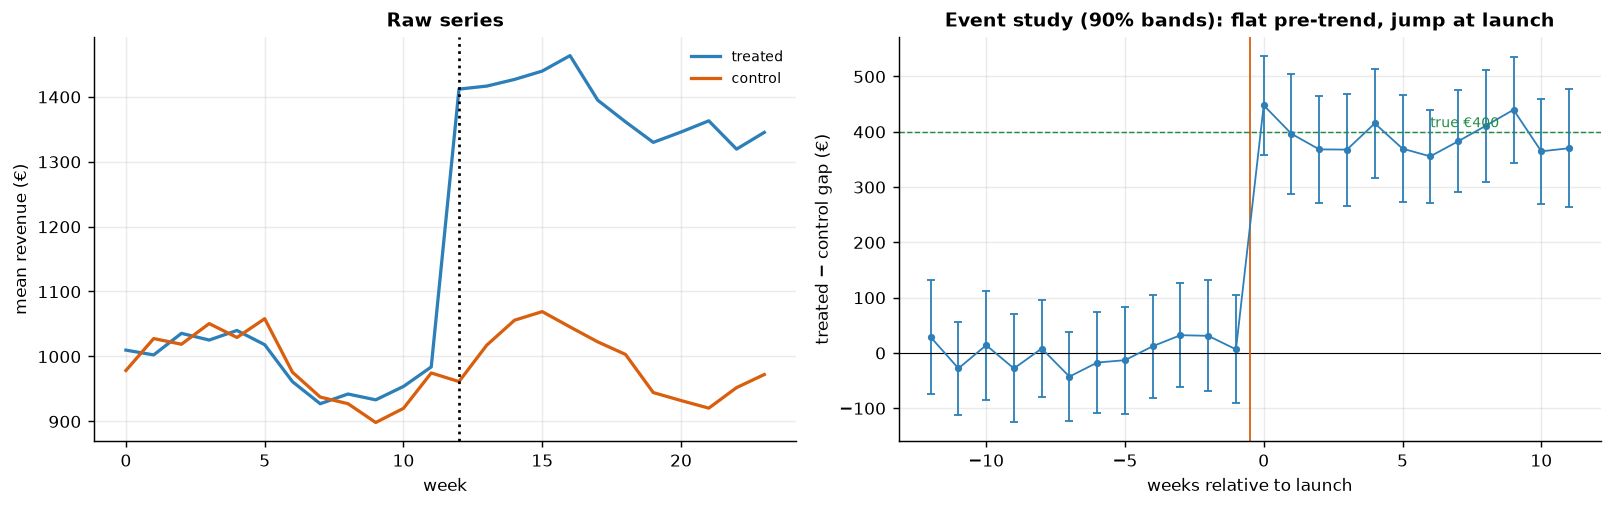

In [4]:
# event study WITH uncertainty: per-week treated−control gap ± 90% band, recentred on the pre-launch mean.
piv = df.pivot_table(index="t", columns="group", values="revenue", aggfunc="mean")
sd_ = df.pivot_table(index="t", columns="group", values="revenue", aggfunc="std")
n_  = df.pivot_table(index="t", columns="group", values="revenue", aggfunc="count")
gap = piv[1] - piv[0]
se  = np.sqrt(sd_[1]**2 / n_[1] + sd_[0]**2 / n_[0])          # SE of each week's treated−control gap
pre = gap.index < LAUNCH
gap_centered = gap - gap[pre].mean()
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
g = df.groupby(["t","group"])["revenue"].mean().unstack()
ax[0].plot(g.index, g[1], color=plots.BLUE, lw=1.8, label="treated"); ax[0].plot(g.index, g[0], color=plots.ORANGE, lw=1.8, label="control")
ax[0].axvline(LAUNCH, color="k", ls=":"); ax[0].set_xlabel("week"); ax[0].set_ylabel("mean revenue (€)"); ax[0].set_title("Raw series"); ax[0].legend(frameon=False, fontsize=8)
ax[1].errorbar(gap_centered.index - LAUNCH, gap_centered.values, yerr=1.645*se.values,
               color=plots.BLUE, marker="o", lw=1.0, ms=3, capsize=2)
ax[1].axhline(0, color="k", lw=0.6); ax[1].axvline(-0.5, color=plots.ORANGE, lw=1)
ax[1].axhline(TRUE, color=plots.GREEN, ls="--", lw=0.8); ax[1].text(6, TRUE+8, f"true €{TRUE:.0f}", fontsize=8, color=plots.GREEN)
ax[1].set_xlabel("weeks relative to launch"); ax[1].set_ylabel("treated − control gap (€)"); ax[1].set_title("Event study (90% bands): flat pre-trend, jump at launch")
fig.tight_layout()
lead_abs = gap_centered[pre].abs().mean(); lead_se = se[pre].mean()
n_out = int((gap_centered[pre].abs() > 1.645 * se[pre]).sum())
print(f"Pre-launch leads scatter around 0 within their 90% bands ({n_out} of {int(pre.sum())} exclude 0):\n"
      f"  mean |gap| €{lead_abs:.0f}, on the order of the per-week noise SE €{lead_se:.0f} —\n"
      f"  consistent with parallel trends, not a pre-trend.\n"
      f"  (Centred leads average exactly 0 by construction, so it is their SPREAD vs\n"
      f"  the noise band, not a mean, that carries the evidence.)\n"
      f"  Post-launch gaps jump to ≈€{TRUE:.0f}.")

**How to read the event study (right panel).** This is the single most important plot in a DiD analysis.
Each dot is the treated-minus-control revenue gap in one week, relative to launch (week 0). Each dot now carries a
**90% uncertainty band**. The story we *want* to see, and do: the pre-launch dots are **flat and their bands
comfortably include zero** — that is the honest content of "parallel trends look credible" (a lead whose band
*excluded* zero would be the red flag), and the assumption the whole method rests on — and then they **jump to ≈ €400 at
launch** and stay there. A rising or falling pre-launch trend would have been a red flag that the two groups
were already diverging, and we'd have had to abandon DiD for synthetic control (notebook 07). The left panel
shows the raw series so you can see both groups riding the same seasonal wave.

**The same picture, twice — and why we redraw it in a moment.** The gaps above are computed
*nonparametrically*: a per-week treated-minus-control difference of means, with a band built from the
between-store spread in that week alone. Step 0 immediately below re-derives exactly these $\beta_k$ from
a **regression** with store and week fixed effects, and gives them **store-clustered** standard errors —
the bands that a referee would ask for. Same dots, honest error bars; compare the two panels as you go.

## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst would do here **without** it. The answer is
not a different analysis: it is the *same estimand* (the ATT of §3), identified by the *same two
assumptions* (parallel trends + no anticipation), estimated with the simplest tool that is still
correct. The causal work lives in the identification argument, not in the machinery — and it is worth
seeing that once, cleanly, before the likelihood and the priors arrive and start doing work of their own.

**The estimator, naked.** The canonical **2×2 DiD** is four cell means and two subtractions:

$$\widehat{\text{ATT}}_{2\times 2}\;=\;\big(\bar y^{\,T}_{\text{post}}-\bar y^{\,T}_{\text{pre}}\big)\;-\;\big(\bar y^{\,C}_{\text{post}}-\bar y^{\,C}_{\text{pre}}\big),$$

with $T$ the pilot stores and $C$ the controls. Run as a regression on the store-week panel,

$$Y_{st}\;=\;\beta_0+\beta_1 D_s+\beta_2 \text{post}_t+\beta_3\,\big(D_s\times\text{post}_t\big)+\varepsilon_{st},$$

the interaction coefficient $\beta_3$ **is** that difference of differences, algebraically — no
approximation. So `cl.did_2x2` returns one number, and it is the ATT.

**The covariance choice is not a detail — it is the estimate's other half.** A point estimate without a
defensible standard error is half an answer, and the *default* standard error here is indefensible. Our
960 rows are not 960 independent observations: they are 40 stores watched for 24 weeks, and a store's
weeks resemble each other (a shared baseline $\alpha_s$; in real chains, serially-correlated local
shocks on top). The information content of the panel is closer to **40** than to 960. **Clustering on
store** is the classical fix — it lets the errors be arbitrarily correlated *within* a store and asks
only for independence *across* stores, so the 40 stores, not the 960 rows, become the unit of
inference. That correction is the point of **Bertrand–Duflo–Mullainathan (2004)**, whose famous finding
is that ignoring within-panel correlation can leave DiD standard errors off by a factor of five or more.

We therefore fit the same regression **twice** — once with iid ("nonrobust") errors, once clustered on
store — and print both. The point estimate will be identical to the last decimal; only the story about
its precision changes. Watch which direction it moves, because it is not the direction most people
expect.

In [5]:
from cmp import classical as cl

# --- The canonical 2x2 DiD: the interaction coefficient IS the ATT (SEs clustered on store) ---
att_cluster = cl.did_2x2(df, outcome="revenue", unit="unit", time="t", treated="group", post="post")

# --- The SAME regression, the SAME point estimate, an iid ("nonrobust") standard error ---
d_ = df.rename(columns={"revenue": "_y", "group": "_g", "post": "_p"})
att_iid = cl.ols(d_, "_y ~ _g*_p", target="_g:_p", cov="nonrobust", name="ATT (2x2 DiD), iid SE")
# ... and, from that same fit, the coefficient on group alone: the pilot-vs-control LEVEL gap.
# It is not our estimand, but it is the contrast that exposes what iid SEs get wrong.
lvl_iid = cl.ols(d_, "_y ~ _g*_p", target="_g", cov="nonrobust", name="pilot-control level gap, iid SE")
lvl_cls = cl.ols(d_, "_y ~ _g*_p", target="_g", cov="cluster", cluster="unit",
                 name="pilot-control level gap, clustered")

print(f"THE ESTIMAND — the ATT, i.e. the 2x2 DiD interaction ({att_cluster.n:,} store-weeks, "
      f"{att_cluster.extra['n_clusters']} stores).")
print("One point estimate; two stories about how precise it is:")
print(f"  iid       : {att_iid.line('€')}")
print(f"  clustered : {att_cluster.line('€')}")
print(f"  -> clustering multiplies the DiD's SE by x{att_cluster.se / att_iid.se:.2f}")
print("\nA DIFFERENT contrast, from the very same fit — the pilot-vs-control LEVEL gap:")
print(f"  iid SE €{lvl_iid.se:.1f}   vs   clustered SE €{lvl_cls.se:.1f}"
      f"   ->  the iid SE was x{lvl_cls.se / lvl_iid.se:.1f} TOO NARROW.")

inside = att_cluster.ci[0] <= true_effect <= att_cluster.ci[1]
print(f"\nGRADE vs the planted truth (€{true_effect:.0f}/store/week): the estimate is off by "
      f"€{att_cluster.estimate - true_effect:+.0f},")
print(f"  and the truth falls {'INSIDE' if inside else 'OUTSIDE'} the clustered 90% CI.")

# --- BDM's actual mechanism, isolated: SERIALLY-CORRELATED within-store shocks ---
# Our DGP's weekly shocks are iid over time. Real store revenue is not: a good month tends to be
# followed by another good month. Rebuild the SAME panel with AR(1) shocks of the same marginal
# SD (80) and sweep the persistence rho, averaging the SEs over 10 fresh panels per rho (a single
# panel's SE is itself noisy). Only the shocks change; the estimator and the truth do not.
def ar1_panel(rho, seed, n_s=40, n_w=24):
    rng = np.random.default_rng(seed)
    fx = rng.normal(1000, 150, n_s)
    tr = np.zeros(n_s, bool); tr[: n_s // 2] = True; rng.shuffle(tr)
    season = 60 * np.sin(2 * np.pi * np.arange(n_w) / 12)
    rows = []
    for s in range(n_s):
        e = np.empty(n_w); e[0] = rng.normal(0, 80)
        innov = rng.normal(0, 80 * np.sqrt(1 - rho ** 2), n_w)   # holds the marginal SD at 80
        for t_ in range(1, n_w):
            e[t_] = rho * e[t_ - 1] + innov[t_]
        rows.append(pd.DataFrame({"unit": s, "t": np.arange(n_w), "group": int(tr[s]),
                                  "post": (np.arange(n_w) >= LAUNCH).astype(int),
                                  "revenue": fx[s] + season
                                             + TRUE * (np.arange(n_w) >= LAUNCH) * tr[s] + e}))
    return pd.concat(rows, ignore_index=True)

print("\nBDM's mechanism, isolated: the SAME panel with serially-correlated (AR(1)) weekly shocks.")
print("  rho   mean clustered SE   mean iid SE   ratio      (10 panels per rho)")
for rho in (0.0, 0.5, 0.8, 0.95):
    se_c, se_i = [], []
    for sd_ in range(10):
        p_ = ar1_panel(rho, seed=200 + sd_)
        se_c.append(cl.did_2x2(p_, outcome="revenue", unit="unit", time="t",
                               treated="group", post="post").se)
        se_i.append(cl.ols(p_.rename(columns={"revenue": "_y", "group": "_g", "post": "_p"}),
                           "_y ~ _g*_p", target="_g:_p", cov="nonrobust").se)
    print(f"  {rho:<5.2f} {np.mean(se_c):>16.1f} {np.mean(se_i):>13.1f} {np.mean(se_c)/np.mean(se_i):>7.2f}")
print("  -> as persistence rises, the DiD's TRUE (clustered) SE roughly doubles, while")
print("     the iid SE sits there unmoved: the nonrobust formula cannot see serial")
print("     correlation at all. That blindness is the gap BDM measured.")
print("     (The ratio dips again at rho=0.95: a near-permanent shock behaves like a")
print("      store baseline and cancels in the DiD contrast. It is INTERMEDIATE")
print("      persistence — outliving the pre/post boundary, but not the panel —")
print("      that does the most damage.)")

THE ESTIMAND — the ATT, i.e. the 2x2 DiD interaction (960 store-weeks, 40 stores).
One point estimate; two stories about how precise it is:
  iid       : 390.49€  [90% CI 350.95€, 430.03€]  ·  SE 24.02  ·  nonrobust
  clustered : 390.49€  [90% CI 370.06€, 410.92€]  ·  SE 12.41  ·  cluster-robust by unit (40 clusters)
  -> clustering multiplies the DiD's SE by x0.52

A DIFFERENT contrast, from the very same fit — the pilot-vs-control LEVEL gap:
  iid SE €17.0   vs   clustered SE €51.5   ->  the iid SE was x3.0 TOO NARROW.

GRADE vs the planted truth (€400/store/week): the estimate is off by €-10,
  and the truth falls INSIDE the clustered 90% CI.

BDM's mechanism, isolated: the SAME panel with serially-correlated (AR(1)) weekly shocks.
  rho   mean clustered SE   mean iid SE   ratio      (10 panels per rho)


  0.00               9.4          23.6    0.40
  0.50              14.9          23.5    0.63


  0.80              20.4          23.4    0.87


  0.95              18.1          23.2    0.78
  -> as persistence rises, the DiD's TRUE (clustered) SE roughly doubles, while
     the iid SE sits there unmoved: the nonrobust formula cannot see serial
     correlation at all. That blindness is the gap BDM measured.
     (The ratio dips again at rho=0.95: a near-permanent shock behaves like a
      store baseline and cancels in the DiD contrast. It is INTERMEDIATE
      persistence — outliving the pre/post boundary, but not the panel —
      that does the most damage.)


**Read the two ratios together — the lesson is not "clustering widens intervals".** On our estimand
(the interaction) clustering *shrank* the standard error, roughly halving it. On the level gap from the
identical regression, clustering *inflated* it several-fold. Both are correct, and the mechanism is the
same object seen from two sides: each store carries a time-invariant baseline $\alpha_s$ (sd €150 by
construction — larger than the €80 weekly noise).

- The **level gap** compares *different stores*, so it is exposed to that baseline scatter — but the iid
  formula, believing it has 960 independent rows, divides the scatter by $\sqrt{960}$ instead of by
  $\sqrt{40}$. It reports a precision the data never had. This is the classic anti-conservative failure,
  and it is the one that ends careers: a confident interval around a number you cannot actually resolve.
- The **DiD interaction** compares each store *against its own past*, so $\alpha_s$ cancels out of the
  contrast entirely. But it does *not* cancel out of the pooled residual: iid OLS still charges the
  estimate for a baseline scatter it never used. The cluster-robust sandwich looks at the 40
  store-level trajectories directly, notices the cancellation, and hands back the honest — here,
  *smaller* — standard error.

So the iid SE is not "conservative" or "anti-conservative" as a rule. It is simply **wrong in a
direction you cannot predict without doing the clustering**, and the sign of the error flips between two
coefficients of the same fit. That is the whole argument for making the covariance choice explicit
rather than accepting a default.

The rho sweep then isolates **Bertrand–Duflo–Mullainathan's own case**: keep everything, and make only
the weekly shocks persistent (a good month tends to follow a good month, as real store revenue does).
Read the two SE columns down the table. The **clustered** SE climbs steeply with persistence up to
$\rho \approx 0.8$, then eases at $\rho = 0.95$ for the reason printed beneath the table (a near-permanent
shock behaves like a store baseline and differences out of the contrast, so it is *intermediate*
persistence that does the most damage) — that is real uncertainty, and it is really there. The **iid** SE barely twitches, because serial correlation is
not a quantity that appears anywhere in its formula: the nonrobust estimator is not *underestimating*
this uncertainty so much as it is structurally unable to perceive it. Persistence could double the true
sampling variability of your DiD and the default `statsmodels` interval would report the same width it
always did, with the same confident three decimal places. Our simulated chain is unusually kind on this
axis (its weekly shocks are iid by construction); **your** panel will not be, which is why clustering on
the panel unit is not optional.

**Hold on to this number.** The clustered standard error above is the classical read's honest width, and
it will come back — pointedly — in **5x**, where we lay it next to the Bayesian posterior.

PRE-PERIOD (11 leads, k<0) — the parallel-trends evidence:
  0 of 11 lead CIs exclude zero (at 90%, ~1 in 10 would by chance alone).
  mean |lead| €23, against a typical lead SE of €36 — noise, not a pre-trend.

POST-PERIOD (12 lags, k>=0) — the dynamic ATT:
  mean €384 (true €400), range €349–€441: an immediate, flat step — no build-up, no decay.
  averaging the lags reproduces the 2x2 ATT above (€390) to within €6.

What this 90% confidence interval does NOT say: that there is a 90% probability the true effect lies inside it. It is a property of the *procedure* — 90% of intervals built this way would cover the truth across repeated samples. This interval either contains the truth or it does not. To get a probability *about the effect itself* — the thing a go/no-go rule like P(lift > cost) >= 0.9 actually needs — you need a posterior. That is what the Bayesian section adds.


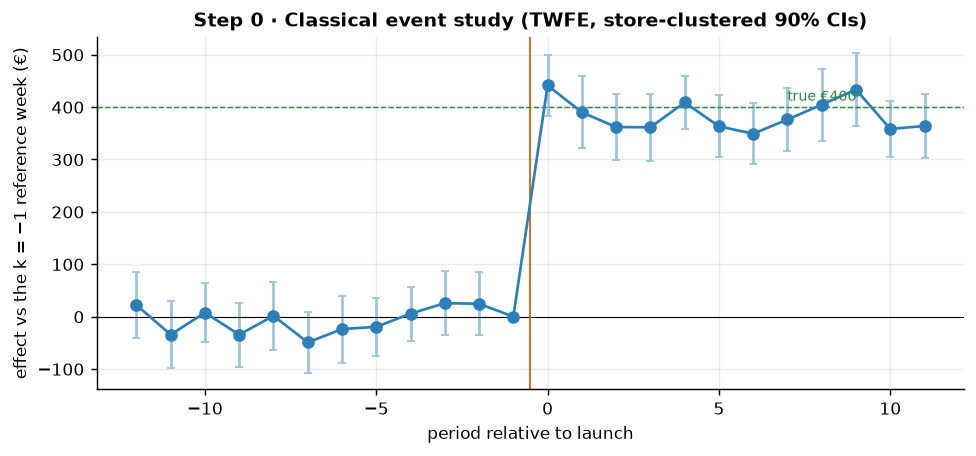

In [6]:
# --- The event study, classically: one coefficient per week relative to launch (TWFE, clustered) ---
d0 = df.assign(k=df["t"] - LAUNCH)                    # k = event time; k = -1 is the reference week
es = cl.event_study(d0, outcome="revenue", unit="unit", rel_time="k", treated="group", base=-1)

fig, ax = plt.subplots(figsize=(7.6, 3.6))
plots.event_study_plot(ax, es["k"], es["estimate"], es["lo"], es["hi"], launch=0,
                       title="Step 0 · Classical event study (TWFE, store-clustered 90% CIs)")
ax.axhline(true_effect, color=plots.GREEN, ls="--", lw=0.8)
ax.text(7, true_effect + 12, f"true €{true_effect:.0f}", fontsize=8, color=plots.GREEN)
ax.set_ylabel("effect vs the k = −1 reference week (€)")
fig.tight_layout()

leads = es[(es["k"] < 0) & (~es["is_base"])]         # k < 0: the parallel-trends EVIDENCE
lags = es[es["k"] >= 0]                              # k >= 0: the dynamic ATT
n_lead_out = int(((leads["lo"] > 0) | (leads["hi"] < 0)).sum())
print(f"PRE-PERIOD ({len(leads)} leads, k<0) — the parallel-trends evidence:")
print(f"  {n_lead_out} of {len(leads)} lead CIs exclude zero (at 90%, ~1 in 10 would by chance alone).")
print(f"  mean |lead| €{leads['estimate'].abs().mean():.0f}, against a typical lead SE of "
      f"€{leads['se'].mean():.0f} — noise, not a pre-trend.")
print(f"\nPOST-PERIOD ({len(lags)} lags, k>=0) — the dynamic ATT:")
print(f"  mean €{lags['estimate'].mean():.0f} (true €{true_effect:.0f}), range €{lags['estimate'].min():.0f}"
      f"–€{lags['estimate'].max():.0f}: an immediate, flat step — no build-up, no decay.")
print(f"  averaging the lags reproduces the 2x2 ATT above (€{att_cluster.estimate:.0f}) to within "
      f"€{abs(lags['estimate'].mean() - att_cluster.estimate):.0f}.")
print("\n" + att_cluster.cannot_say())

**Read-out — the classical answer, in business terms.** The loyalty app lifted revenue in the pilot
stores by the amount printed above, per store per week, net of the seasonal tide; the 90% clustered
confidence interval is narrow enough that the entire interval sits far above any plausible running cost
for the app (§6 does that arithmetic properly). The planted truth is €400 and it sits inside the
interval — the classical estimator is doing its job. The event study says the same thing with more
resolution: **eleven flat leads** (there are twelve pre-launch weeks, but one — $k=-1$ — is spent as
the reference and pinned to zero by construction, so eleven are free to move and none of them does),
then an immediate step — to the lag mean printed above — that holds for twelve weeks. The leads are the evidence that makes
parallel trends credible — and the *only* evidence we will ever have for it. If the
leads had trended, this notebook would have ended here, and we would be reaching for synthetic control
(notebook 07) instead.

Notice what has *not* happened yet. No likelihood was written down, no prior was chosen, no sampler ran.
The identification — parallel trends, no anticipation — did all the causal work, and four cell means did
all the estimation. **This is the honest baseline against which the Bayesian section must justify itself**,
and §5x will hold it to that.

**The guardrail — what that confidence interval does *not* say** (printed above, and it will be printed
in the same words in every notebook of this cookbook): it is **not** a 90% probability that the true
effect lies inside it. A confidence interval is a property of the *procedure* — 90% of intervals built
this way would cover the truth across repeated samples — and this particular interval either covers the
truth or it does not. The distinction is not pedantry, and here is exactly where it bites: §6 has to
answer *"what is the probability the app clears its €120/store/week running cost?"* That sentence asks
for a probability **about the effect itself**. The classical apparatus cannot supply one — not because
its arithmetic is worse, but because that quantity does not exist in its vocabulary. It exists in a
posterior. That, and not a better point estimate, is what the next section is for.

## 4 · Estimate — Bayesian difference-in-differences

We now put a number and an interval on that jump. One modeling choice: we first collapse each store's
24 weekly points into a single pre-launch mean and a single post-launch mean. This is primarily the
**Bertrand–Duflo–Mullainathan (2004) serial-correlation guard** — the same hazard Step 0 just
demonstrated on the classical side, where it was handled by *clustering* rather than by collapsing: a store's revenue this week is
correlated with its own revenue last week (autocorrelation), so treating 24 weekly rows per store as 24
*independent* observations prices the panel's uncertainty with a formula that cannot see serial
correlation at all. Step 0 showed that the *direction* of that error is not predictable — on this very
interaction the iid SE came out at x0.52 of the clustered one, i.e. too *wide*, while on the level gap
from the same fit it was 3x too narrow. Collapsing (like clustering) removes the problem instead of
betting on its sign. Collapsing each store to a single pre mean and a
single post mean throws away the within-store time series entirely, so the problem cannot arise. It is a modeling decision, not merely an API constraint — though
CausalPy's `DifferenceInDifferences` also happens to consume this classic **2×2 form** cleanly. The
estimate is the `group × post` interaction coefficient $\beta_3$, i.e. the DiD — **the same $\beta_3$
Step 0 just estimated by OLS.** Everything that follows is therefore a like-for-like comparison: same
estimand, same identification, a different apparatus for expressing uncertainty about it. §5x settles the
account.


**The model behind `est.did`, in symbols.** CausalPy 0.8.1's `LinearRegression` fits, on design row
$\mathbf x_i=(1,\ g_i,\ p_i,\ g_i p_i)^\top$ (intercept, group flag, post flag, interaction; $i$ runs
over the 80 collapsed store-periods — two rows per store):

$$\tilde Y_i \;\sim\; \mathcal N\!\big(\mathbf x_i^\top\boldsymbol\beta,\ \sigma^2\big),\qquad
\beta_j \;\sim\; \mathcal N(0,\ 50^2),\qquad \sigma \;\sim\; \text{HalfNormal}(1),$$

and those priors are **fixed by the library** (verified against the installed source), scaled for data
of order one. On raw euro revenue ($\bar Y\approx$ €1,000, residual spread in the hundreds) a
HalfNormal(1) prior — a normal folded to its positive half, the natural prior for a standard deviation,
which must be $\ge 0$ — on $\sigma$ is absurdly tight: the prior fights the likelihood and drags the effect
low, with a too-narrow interval around the wrong number. So we fit on **standardized** revenue
$\tilde Y=(Y-\bar Y)/s_Y$ and back-transform only the interaction:

$$\widehat{\text{DiD}}_{\text{€}} \;=\; \beta_3 \cdot s_Y$$

($\bar Y$ is absorbed by the intercept and main effects; the coefficient of a 0/1 interaction only
needs the *scale* $s_Y$ undone). **The general lesson deserves stating as a lesson:** check your
library's default prior scale against your data scale before trusting any fit — defaults tuned for
standardized data will quietly mis-fit raw euros, and the failure mode is a *confident wrong answer*,
not an error message.

In [7]:
agg = df.groupby(["unit","group","post_treatment"])["revenue"].mean().reset_index()
agg["t"] = agg["post_treatment"].astype(int).astype(float)
# CausalPy 0.8.1's LinearRegression ships FIXED priors (beta ~ N(0,50), sigma ~ HalfNormal(1))
# scaled for O(1) data; on revenue ~ €1000 they fight the data and shrink the effect low (and
# too-narrow). We standardize revenue for the fit, then back-transform the effect to euros.
rev_mu, rev_sd = agg["revenue"].mean(), agg["revenue"].std()
agg["revenue_z"] = (agg["revenue"] - rev_mu) / rev_sd
result = est.did(agg, formula="revenue_z ~ 1 + group*post_treatment", fast=FAST)
impact = np.asarray(result.causal_impact).ravel() * rev_sd    # standardized effect -> euros
print(f"DiD effect €{impact.mean():.0f}/store/week (true €{true_effect:.0f})  ·  "
      f"90% credible interval (90% posterior probability the true effect lies inside) "
      f"[€{np.quantile(impact,0.05):.0f}, €{np.quantile(impact,0.95):.0f}]")
print(f"DiD convergence: {est.convergence_report(result.idata)["summary"]}")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


DiD effect €393/store/week (true €400)  ·  90% credible interval (90% posterior probability the true effect lies inside) [€274, €515]
DiD convergence: max r-hat 1.000 - min ESS 1596 - divergences 0


**Reading the sampler's health check (`DiD convergence:` above).** Those three numbers say whether the MCMC sampler — the algorithm that draws samples from the posterior — actually converged, and this same three-number line travels with every Bayesian fit below. **R-hat** compares the variance within each chain to the variance across the independent chains; 1.00 is perfect and **≤ 1.01 is the usual pass bar**. **ESS** (effective sample size) is how many genuinely *independent* draws our autocorrelated chains are worth — a few hundred is ample for a posterior mean or interval; bigger is better. **Divergences** are steps where the sampler broke down and silently distrusts that region — **you want 0**. Under this notebook's FAST teaching profile the chains are deliberately short, so R-hat can drift to ~1.02–1.03 and PyMC may print a *“problems during sampling”* / *“effective sample size… smaller than 100”* notice above — a benign artifact of the small draw count that clears in a FULL run, not a broken model. The real backstop for trusting this estimate is the three-witnesses calibration in Step 5, not any single sampler line.

### 4b · Model criticism — the posterior predictive check

Before we *read an effect off* this model, we ask whether it could plausibly have **generated the data
at all**. The 2×2 model is deliberately coarse — four cell means plus one shared Gaussian noise term;
every store baseline $\alpha_s$ it doesn't describe has to live inside that noise. We draw replicated
datasets from the fitted model's posterior predictive, back-transform them to euros, and overlay them
on the 80 observed store-period revenues. If the real distribution (spread, lumpiness, tails) looked
unlike anything the model can produce, no interval downstream would deserve trust. And notice one thing
*because* it foreshadows 5c: for this coarse model to pass, its replicate spread must be **fat** — the
between-store baseline scatter sits in $\sigma$ — and that same fat $\sigma$ is what will make the
effect interval conservative.

PPC: 90% of the 80 observed store-period revenues fall inside their replicate 5–95% band (≈90% if calibrated) — no gross misfit.
Posterior residual σ ≈ €170 — note how fat: it must absorb the between-store baseline spread (sd €150 by construction) that the 4-mean model doesn't describe. 5c shows the price; 5d collects the refund.


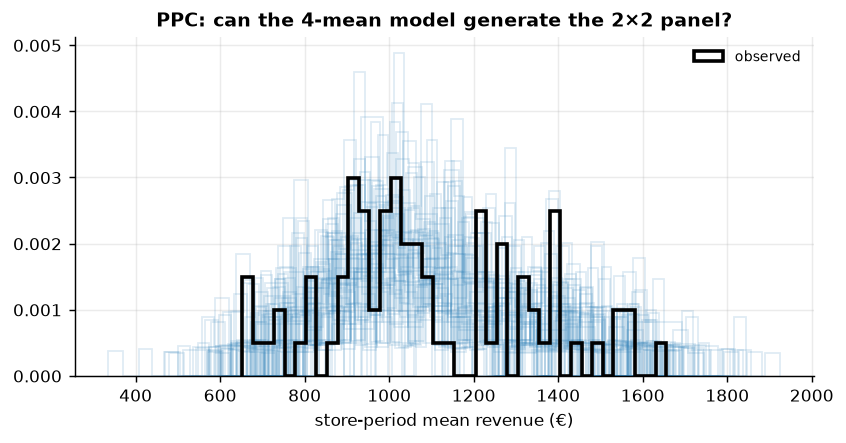

In [8]:
# PPC: replicate the 80 collapsed revenues from the fitted model's posterior predictive (y_hat is
# sampled on the standardized scale, so back-transform each replicate to euros).
yh = result.idata.posterior_predictive["y_hat"]
y_rep_all = (yh.stack(sample=("chain", "draw")).transpose("sample", "obs_ind", "treated_units")
               .values.reshape(-1, len(agg)) * rev_sd + rev_mu)
y_obs = agg["revenue"].values
rng_ppc = np.random.default_rng(0)
y_rep = y_rep_all[rng_ppc.choice(len(y_rep_all), size=min(40, len(y_rep_all)), replace=False)]
fig, ax = plt.subplots(figsize=(6.6, 3.5))
plots.ppc_plot(ax, y_obs, y_rep, title="PPC: can the 4-mean model generate the 2×2 panel?")
ax.set_xlabel("store-period mean revenue (€)"); fig.tight_layout()
lo_ppc = np.quantile(y_rep_all, 0.05, axis=0); hi_ppc = np.quantile(y_rep_all, 0.95, axis=0)
cov_ppc = float(np.mean((y_obs >= lo_ppc) & (y_obs <= hi_ppc)))
sig_eur = float(result.idata.posterior["y_hat_sigma"].mean()) * rev_sd
verdict = "no gross misfit" if 0.82 <= cov_ppc <= 0.98 else "a possible misfit — inspect the tails"
print(f"PPC: {cov_ppc:.0%} of the 80 observed store-period revenues fall inside their replicate 5–95% band "
      f"(≈90% if calibrated) — {verdict}.")
print(f"Posterior residual σ ≈ €{sig_eur:.0f} — note how fat: it must absorb the between-store baseline spread "
      f"(sd €150 by construction) that the 4-mean model doesn't describe. 5c shows the price; 5d collects the refund.")

## 5 · Validate — 2×2 cross-check and the placebo pair

Cross-check the Bayesian estimate against the 2×2 — computed here **by hand**, from four cell means,
so you can see the arithmetic that Step 0's regression performs internally (the cell below verifies the
two agree to the last euro). With revenue **standardized** before
the fit (so CausalPy's default O(1)-scaled priors don't shrink a €400 effect sitting on €1000 revenue),
the two now **agree** and both land on the planted €400 with the truth inside the interval. Then
**falsify**: run DiD on the *pre-period only*, splitting it into a fake "before/after" at week 6. There
was no treatment then, so the placebo effect should be ≈ 0 — a large one would mean our design
manufactures effects. That is placebo-in-**time**; its mirror, placebo-in-**group** (fake treated stores instead of a fake launch date), follows in 5b.

Hand-computed 2×2 €390 = Step 0's OLS interaction €390 (identical by algebra, asserted above — the regression is just bookkeeping for the four means).
Bayesian €393  ·  2×2 €390  ·  true €400  ·  placebo (no real effect) €17 ± SE €33 — within sampling noise of zero


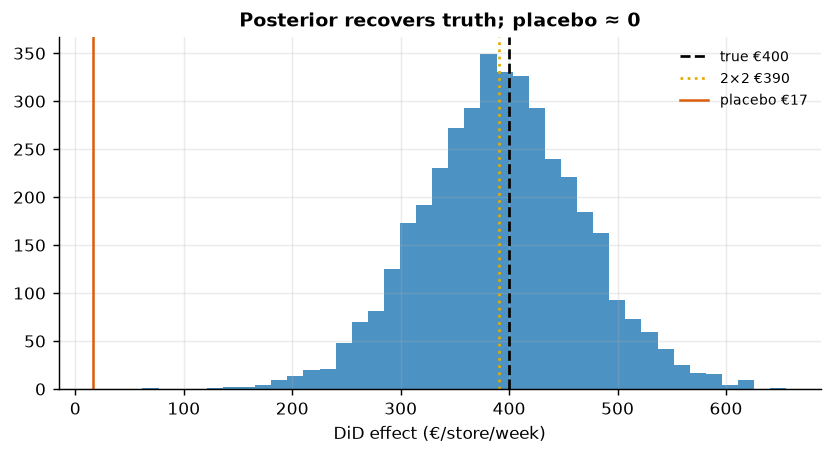

In [9]:
m = df.groupby(["group","post"])["revenue"].mean()
did_2x2 = (m[1,1]-m[1,0]) - (m[0,1]-m[0,0])     # four cell means, two subtractions — the naked estimator
assert abs(did_2x2 - att_cluster.estimate) < 1e-6   # ... and it IS Step 0's regression coefficient beta_3
# placebo: pre-period only, fake launch at week 6
pre = df[df.t < LAUNCH].copy(); pre["fake_post"] = (pre.t >= 6).astype(int)
mp = pre.groupby(["group","fake_post"])["revenue"].mean()
placebo = (mp[1,1]-mp[1,0]) - (mp[0,1]-mp[0,0])
mp_sd = pre.groupby(["group","fake_post"])["revenue"].std()
mp_n  = pre.groupby(["group","fake_post"])["revenue"].count()
placebo_se = float(np.sqrt((mp_sd**2 / mp_n).sum()))   # SE of the placebo 2×2 = quadrature of the four cell-mean SEs
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(impact, bins=40, color=plots.BLUE, alpha=0.85)
ax.axvline(true_effect, color="k", ls="--", label=f"true €{true_effect:.0f}")
ax.axvline(did_2x2, color=plots.GOLD, ls=":", label=f"2×2 €{did_2x2:.0f}")
ax.axvline(placebo, color=plots.ORANGE, lw=1.4, label=f"placebo €{placebo:.0f}")
ax.set_xlabel("DiD effect (€/store/week)"); ax.set_title("Posterior recovers truth; placebo ≈ 0"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"Hand-computed 2×2 €{did_2x2:.0f} = Step 0's OLS interaction €{att_cluster.estimate:.0f} "
      f"(identical by algebra, asserted above — the regression is just bookkeeping for the four means).")
print(f"Bayesian €{impact.mean():.0f}  ·  2×2 €{did_2x2:.0f}  ·  true €{true_effect:.0f}  ·  "
      f"placebo (no real effect) €{placebo:.0f} ± SE €{placebo_se:.0f} — within sampling noise of zero")

### 5b · Placebo-in-group — a permutation null from the control stores

The time placebo asked "does our design manufacture effects out of **seasonality**?" The group placebo
asks the complementary question: "…out of **store-to-store noise**?" Together they bracket the two ways
a fake effect could arise in a panel. Take only the 20 control stores — the app never touched them, so
the true effect there is *exactly zero* — declare a random half "pseudo-treated", and run the very same
2×2 at the real launch week. Repeating over many random relabelings traces out the **permutation
null**: the full distribution of DiD estimates our pipeline produces *when nothing is going on*. Two
read-outs: **(i)** a permutation p-value — the share of relabelings whose placebo estimate beats the
real one in magnitude; **(ii)** an **assumption-light uncertainty cross-check** — the null's spread is
how far store noise alone can move this estimator, with no likelihood, no priors, no Gaussian anywhere.
File that second one away: compare it with the width of the Bayesian interval from Step 4 as you read
5c and 5d.

Permutation null: sd €14, largest |placebo DiD| €37. The real estimate €393 is ~28× the null's sd — store noise does not produce numbers like this: permutation p ≤ 0.005 (resolution floor 1/201).
Cross-check: noise alone moves this estimator by ~±€28 (2 sd — and a 10-vs-10 split is even noisier than the real 20-vs-20), yet the Bayesian interval above is ±€121 wide. An assumption-light hint that the 2×2 interval is conservative; 5c quantifies that, 5d fixes it.


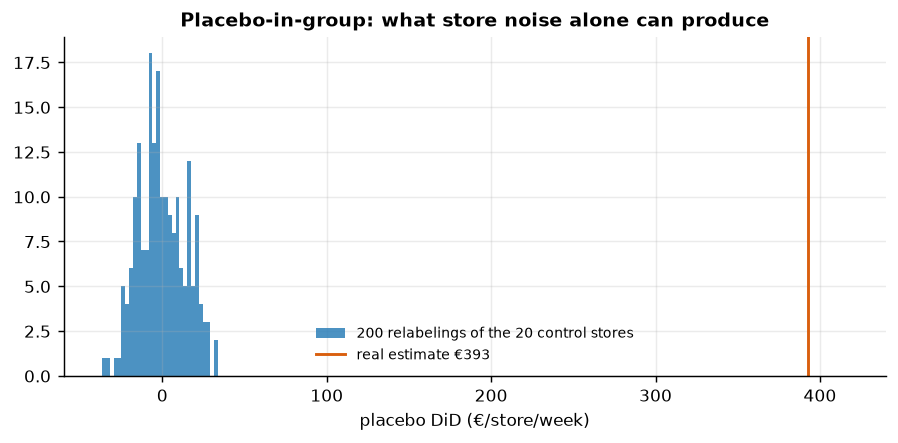

In [10]:
NPERM = 80 if FAST else 200
# On a balanced panel the 2×2 DiD equals the difference in mean per-store (post − pre) changes,
# so permuting store-level deltas IS permuting the 2×2 — one pandas pivot, then pure numpy.
ctrl_delta = (df[df.group == 0].pivot_table(index="unit", columns="post", values="revenue", aggfunc="mean")
                .pipe(lambda p: p[1] - p[0]).values)
rng_perm = np.random.default_rng(7); n_c = len(ctrl_delta)
perm = np.empty(NPERM)
for b in range(NPERM):
    fake = rng_perm.permutation(n_c) < n_c // 2
    perm[b] = ctrl_delta[fake].mean() - ctrl_delta[~fake].mean()
real_did = float(impact.mean())
p_perm = (1 + int((np.abs(perm) >= abs(real_did)).sum())) / (NPERM + 1)   # add-one permutation p
fig, ax = plt.subplots(figsize=(7.0, 3.5))
ax.hist(perm, bins=30, color=plots.BLUE, alpha=0.85, label=f"{NPERM} relabelings of the 20 control stores")
ax.axvline(real_did, color=plots.ORANGE, lw=1.6, label=f"real estimate €{real_did:.0f}")
ax.set_xlim(min(perm.min() * 1.3, -60), real_did * 1.12)
ax.set_xlabel("placebo DiD (€/store/week)"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Placebo-in-group: what store noise alone can produce")
fig.tight_layout()
half_bayes = float(np.quantile(impact, 0.95) - np.quantile(impact, 0.05)) / 2
print(f"Permutation null: sd €{perm.std():.0f}, largest |placebo DiD| €{np.abs(perm).max():.0f}. The real estimate "
      f"€{real_did:.0f} is ~{abs(real_did)/perm.std():.0f}× the null's sd — store noise does not produce numbers like "
      f"this: permutation p ≤ {p_perm:.3f} (resolution floor 1/{NPERM + 1}).")
print(f"Cross-check: noise alone moves this estimator by ~±€{2 * perm.std():.0f} (2 sd — and a 10-vs-10 split is even "
      f"noisier than the real 20-vs-20), yet the Bayesian interval above is ±€{half_bayes:.0f} wide. An "
      f"assumption-light hint that the 2×2 interval is conservative; 5c quantifies that, 5d fixes it.")

### 5c · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test is whether the estimator is **centred on the truth over repeated samples** and whether its 90% interval **covers** the truth at the stated rate. We refit on many fresh samples (a small fast fit each; their sampler chatter is silenced below) and check both. Coverage can fail in **both** directions — an interval can be too *narrow* (overconfident) or too *wide* (conservative) — so beside counting hits we also compare the interval's width against the true seed-to-seed scatter.

DiD across 20 seeds: mean €403 (true €400)  bias +3  sd €11  ·  90% interval covers truth in 20/20 seeds.
But read 20/20 carefully: the headline interval's ±€121 half-width is ~11× the true seed-to-seed scatter (sd €11) — OVER-coverage, not perfect calibration. The 2×2 collapse leaves between-store baseline spread in the residual, so the interval is honest but conservative; downstream bounds (the break-even running cost, the stress-table probabilities) inherit that width — cautious, not sharp. (Store fixed effects / within-store differencing would tighten it.)


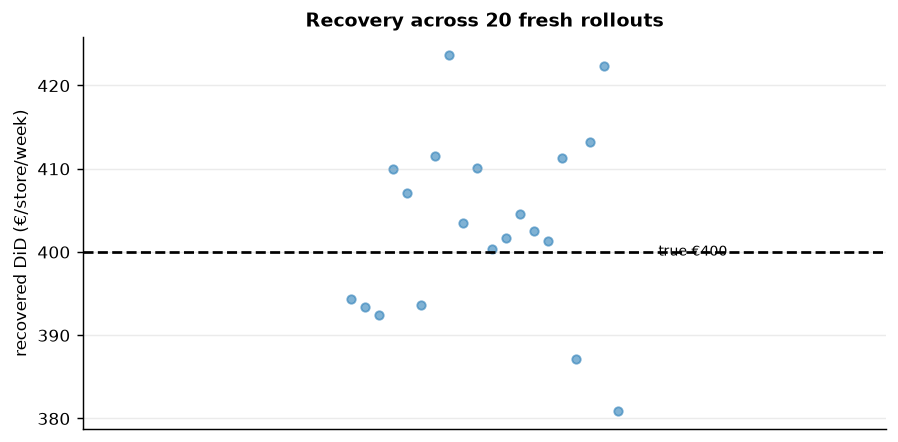

In [11]:
# --- Recovery across many seeds: does the DiD recover €400 and cover it? ---
NSEED = 8 if FAST else 20
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the per-seed refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed above; the same trick pymc's own
# _quiet_logging uses — the low-ESS notice is logged at ERROR level); restored at the end of the cell
pts = []; cov = 0
for sd in range(NSEED):
    d, te = dgp.did_rollout(n_stores=40, n_weeks=24, launch_week=LAUNCH, seed=100 + sd)
    ag = d.groupby(["unit", "group", "post_treatment"])["revenue"].mean().reset_index()
    ag["t"] = ag["post_treatment"].astype(int).astype(float)
    sv = ag["revenue"].std(); ag["revenue_z"] = (ag["revenue"] - ag["revenue"].mean()) / sv
    r = est.did(ag, formula="revenue_z ~ 1 + group*post_treatment", fast=True)
    im = np.asarray(r.causal_impact).ravel() * sv
    pts.append(im.mean()); lo, hi = np.quantile(im, [.05, .95]); cov += int(lo <= te <= hi)
pts = np.array(pts)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(np.linspace(-0.2, 0.2, NSEED), pts, s=22, color=plots.BLUE, alpha=0.6)
ax.axhline(true_effect, color="k", ls="--"); ax.text(0.26, true_effect, f"true €{true_effect:.0f}", fontsize=8, va="center")
ax.set_xticks([]); ax.set_xlim(-0.6, 0.6); ax.set_ylabel("recovered DiD (€/store/week)")
ax.set_title(f"Recovery across {NSEED} fresh rollouts"); fig.tight_layout()
print(f"DiD across {NSEED} seeds: mean €{pts.mean():.0f} (true €{true_effect:.0f})  bias {pts.mean()-true_effect:+.0f}  "
      f"sd €{pts.std():.0f}  ·  90% interval covers truth in {cov}/{NSEED} seeds.")
half = float(np.quantile(impact, 0.95) - np.quantile(impact, 0.05)) / 2
print(f"But read {cov}/{NSEED} carefully: the headline interval's ±€{half:.0f} half-width is "
      f"~{half/pts.std():.0f}× the true seed-to-seed scatter (sd €{pts.std():.0f}) — OVER-coverage, not perfect "
      f"calibration. The 2×2 collapse leaves between-store baseline spread in the residual, so the interval is "
      f"honest but conservative; downstream bounds (the break-even running cost, the stress-table probabilities) "
      f"inherit that width — cautious, not sharp. (Store fixed effects / within-store differencing would tighten it.)")
_pml.setLevel(_pml_lvl)

### 5d · Completing the diagnosis — within-store differencing

5c's verdict was "unbiased and covered, but roughly an order of magnitude too wide". The cause is
visible in the model spec of Step 4: the 2×2 pools stores, so the store baselines $\alpha_s$ (sd €150
by construction) sit in the residual $\sigma$ — the PPC in 4b showed exactly that fat $\sigma$. The
cure is the oldest trick in the fixed-effects book: **difference each store against itself**. Collapse
every store to a single number,

$$\Delta_s \;=\; \bar Y_{s,\text{post}} - \bar Y_{s,\text{pre}},$$

which removes $\alpha_s$ *exactly* (it is time-invariant, so it appears in both means and cancels)
while keeping the Bertrand–Duflo–Mullainathan two-period guard from Step 4. The DiD becomes a
one-coefficient comparison of store-level *changes*,

$$\Delta_s \;\sim\; \mathcal N\!\big(\gamma_0 + \gamma_1 D_s,\ \sigma_\Delta^2\big),\qquad
\widehat{\text{DiD}} \;=\; \gamma_1 \;=\; \bar\Delta_{D=1}-\bar\Delta_{D=0},$$

with $\gamma_0$ the control stores' mean change (the seasonal tide) and $\sigma_\Delta$ containing only
averaged week-level noise, no store baselines. Same estimand, same point estimate — radically smaller
residual. It's a ten-line PyMC model with weak priors on the standardized scale. And the non-negotiable
check: a *tighter* interval is progress only if coverage survives, so we re-run 5c's seed loop on this
estimator — a tightening that broke coverage would be overconfidence wearing a fix's clothes.

Within-store DiD €390 (true €400) · 90% interval [€369, €412] — half-width €21
  vs the pooled 2×2's €121 (~6× tighter)
  convergence: max r-hat 1.000 - min ESS 2128 - divergences 0
Seed loop (20 fresh rollouts): mean €403, seed-to-seed sd €9, coverage 17/20.
  The 90%-interval half-width (≈€17) is ~1.8× the seed scatter,
  where a calibrated 90% interval sits at ≈1.6× (the pooled 2×2 was at ~11×):
  -> tight AND calibrated
  (with only 20 seeds the hit count is itself binomially noisy).
Decision preview: the running cost the app clears with 95% posterior probability
  moves from ~€274 (pooled 2×2) to ~€369/store/week (within-store posterior).


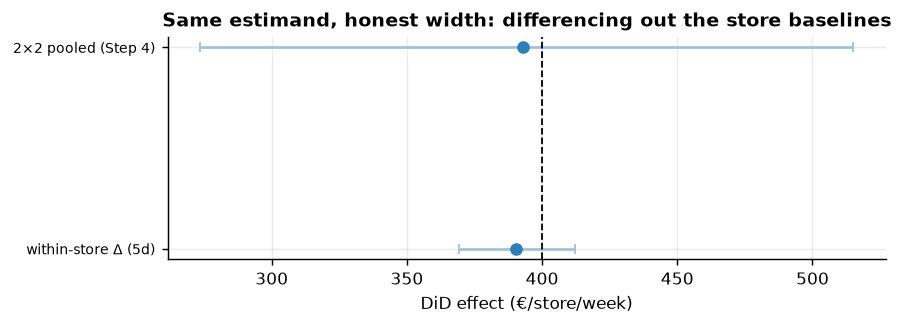

In [12]:
# Within-store differencing: one Delta per store, then a 2-parameter Bayesian comparison of changes.
import logging, pymc as pm
_pml = logging.getLogger("pymc"); _pml_lvl2 = _pml.level
_pml.setLevel(logging.CRITICAL + 1)                      # silence sampler chatter (SamplerWarnings log at ERROR)

def fit_delta(frame, fast):
    """Delta_s ~ N(g0 + g1*D_s, sigma^2), fitted on the standardized scale; returns euro-scale g1 draws."""
    ds = frame["delta"].std()
    with pm.Model():
        g0 = pm.Normal("g0", 0, 5); g1 = pm.Normal("g1", 0, 5)
        sig = pm.HalfNormal("sigma", 1)
        pm.Normal("dz", g0 + g1 * frame["group"].values, sig, observed=frame["delta"].values / ds)
        idata = pm.sample(draws=400 if fast else 1000, tune=400 if fast else 1000,
                          chains=2 if fast else 4, progressbar=False, compute_convergence_checks=False)
    return idata.posterior["g1"].values.ravel() * ds, idata

def delta_frame(frame):
    p = frame.pivot_table(index=["unit", "group"], columns="post", values="revenue", aggfunc="mean").reset_index()
    p["delta"] = p[1] - p[0]
    return p

impact_fe, idata_fe = fit_delta(delta_frame(df), fast=FAST)
cov_fe = 0; pts_fe = []; hw_fe = []
for s_ in range(NSEED):                                   # same seeds as 5c, same loop, tighter estimator
    d_, te_ = dgp.did_rollout(n_stores=40, n_weeks=24, launch_week=LAUNCH, seed=100 + s_)
    im_, _ = fit_delta(delta_frame(d_), fast=True)
    lo_, hi_ = np.quantile(im_, [.05, .95])
    pts_fe.append(im_.mean()); hw_fe.append((hi_ - lo_) / 2); cov_fe += int(lo_ <= te_ <= hi_)
pts_fe = np.array(pts_fe)
_pml.setLevel(_pml_lvl2)
q_w = np.quantile(impact, [.05, .95]); q_f = np.quantile(impact_fe, [.05, .95])
half_w, half_f = (q_w[1] - q_w[0]) / 2, (q_f[1] - q_f[0]) / 2
fig, ax = plt.subplots(figsize=(7.0, 2.6))
plots.forest_plot(ax, ["2×2 pooled (Step 4)", "within-store Δ (5d)"],
                  [impact.mean(), impact_fe.mean()], [q_w[0], q_f[0]], [q_w[1], q_f[1]],
                  ref=true_effect, xlabel="DiD effect (€/store/week)",
                  title="Same estimand, honest width: differencing out the store baselines")
fig.tight_layout()
print(f"Within-store DiD €{impact_fe.mean():.0f} (true €{true_effect:.0f}) · 90% interval "
      f"[€{q_f[0]:.0f}, €{q_f[1]:.0f}] — half-width €{half_f:.0f}\n"
      f"  vs the pooled 2×2's €{half_w:.0f} (~{half_w / half_f:.0f}× tighter)\n"
      f"  convergence: {est.convergence_report(idata_fe)['summary']}")
cal = "tight AND calibrated" if cov_fe / NSEED >= 0.75 else "tight but under-covering — investigate before trusting"
print(f"Seed loop ({NSEED} fresh rollouts): mean €{pts_fe.mean():.0f}, seed-to-seed sd €{pts_fe.std():.0f}, "
      f"coverage {cov_fe}/{NSEED}.\n"
      f"  The 90%-interval half-width (≈€{np.mean(hw_fe):.0f}) is ~{np.mean(hw_fe) / pts_fe.std():.1f}× "
      f"the seed scatter,\n"
      f"  where a calibrated 90% interval sits at ≈1.6× (the pooled 2×2 was at ~11×):\n"
      f"  -> {cal}\n"
      f"  (with only {NSEED} seeds the hit count is itself binomially noisy).")
print(f"Decision preview: the running cost the app clears with 95% posterior probability\n"
      f"  moves from ~€{q_w[0]:.0f} (pooled 2×2) to ~€{q_f[0]:.0f}/store/week (within-store posterior).")

**Read-out.** Same point estimate, an interval several times tighter, and — the part that makes the
tightening legitimate — the seed loop's hit count (printed above) stays statistically consistent with the nominal 90% once you
account for binomial noise on a handful of seeds: the width we removed was redundancy, not protection. Notice that three *independent* witnesses now agree on the
honest uncertainty scale: the permutation null's spread (5b), the seed-to-seed scatter (5c), and the
within-store posterior (5d) — and a fourth, arriving from outside the Bayesian apparatus entirely: Step
0's **cluster-robust standard error**, which landed on that same scale without a single prior (§5x lays
the two side by side). Step 6 below prices the decision with the **conservative** Step-4
posterior on purpose — a rollout case that survives the wide interval is robust — and the break-even
print above shows how much sharper the same case becomes once the analysis earns its precision.

### 5x · Point estimate vs posterior — what the Bayesian layer actually bought

In [13]:
# --- 5x · The classical point estimate vs the Bayesian posterior, on the SAME estimand ---
# The like-for-like classical partner of 5d's within-store model: OLS on the 40 store-level Deltas.
att_delta = cl.ols(delta_frame(df), "delta ~ group", target="group", cov="HC1",
                   name="ATT (within-store Delta, classical)")

rows = [("classical 2×2 · iid SE (WRONG)",       att_iid.estimate,     *att_iid.ci),
        ("classical 2×2 · clustered on store",   att_cluster.estimate, *att_cluster.ci),
        ("classical within-store Δ · HC1",       att_delta.estimate,   *att_delta.ci),
        ("Bayesian 2×2 · CausalPy (Step 4)",     impact.mean(),        *np.quantile(impact, [.05, .95])),
        ("Bayesian within-store Δ · PyMC (5d)",  impact_fe.mean(),     *np.quantile(impact_fe, [.05, .95]))]
print("SAME estimand (the ATT), SAME assumptions (parallel trends + no anticipation);")
print(f"five ways of putting an interval on it. Planted truth = €{true_effect:.0f}.\n")
print(f"{'ATT (€/store/week)':<37}{'est':>6}{'5%':>6}{'95%':>6}{'± half':>8}")
for lab, e, lo, hi in rows:
    print(f"{lab:<37}{e:>6.0f}{lo:>6.0f}{hi:>6.0f}{(hi - lo) / 2:>8.0f}")

ests = [r[1] for r in rows]
hw = {r[0]: (r[3] - r[2]) / 2 for r in rows}
print(f"\nLOCATION — they agree. The five point estimates span just €{max(ests) - min(ests):.0f} "
      f"(€{min(ests):.0f}–€{max(ests):.0f}),")
print(f"  ~{100 * (max(ests) - min(ests)) / true_effect:.0f}% of the effect itself, and every interval "
      f"covers the truth.")
print(f"\nWIDTH — they do not. The classical CLUSTERED half-width (€{hw[rows[1][0]]:.0f}) and the")
print(f"  within-store POSTERIOR (€{hw[rows[4][0]]:.0f}) land on the same scale, while the pooled")
print(f"  Bayesian 2×2 is ~{hw[rows[3][0]] / hw[rows[1][0]]:.0f}× wider than either. The odd one out is the "
      f"Bayesian MODEL,")
print("  not the classical SE — see 4b/5c: that model keeps the store baselines in σ.")

# And the thing only a posterior can answer: a probability ABOUT the effect.
print("\nP(ATT > c) — a probability about the effect, at three candidate running costs:")
print(f"  {'c (€/store/wk)':<16}{'classical':>13}{'Bayes 2×2':>12}{'Bayes within-store':>20}")
for c in (120.0, 300.0, 380.0):
    print(f"  {c:<16.0f}{'not defined':>13}{(impact > c).mean():>12.2f}{(impact_fe > c).mean():>20.2f}")
print("  ('not defined' is not a dodge: a confidence interval has no probability to")
print("   report about a hypothesis. §6's go/no-go rule needs one of these numbers.)")

SAME estimand (the ATT), SAME assumptions (parallel trends + no anticipation);
five ways of putting an interval on it. Planted truth = €400.

ATT (€/store/week)                      est    5%   95%  ± half
classical 2×2 · iid SE (WRONG)          390   351   430      40
classical 2×2 · clustered on store      390   370   411      20
classical within-store Δ · HC1          390   369   412      21
Bayesian 2×2 · CausalPy (Step 4)        393   274   515     121
Bayesian within-store Δ · PyMC (5d)     390   369   412      21

LOCATION — they agree. The five point estimates span just €3 (€390–€393),
  ~1% of the effect itself, and every interval covers the truth.

WIDTH — they do not. The classical CLUSTERED half-width (€20) and the
  within-store POSTERIOR (€21) land on the same scale, while the pooled
  Bayesian 2×2 is ~6× wider than either. The odd one out is the Bayesian MODEL,
  not the classical SE — see 4b/5c: that model keeps the store baselines in σ.

P(ATT > c) — a probability abou

**The honest verdict — what the posterior bought, and what it did not.**

**1 · They agree, and you should say so out loud.** Five estimators — two classical, two Bayesian, plus
the deliberately-wrong iid row — land on the same number, within a few euros of each other and of the
planted €400. That is not a coincidence and it is not a disappointment: **the causal work was done by
the identification, not by the machinery.** Parallel trends plus no anticipation is what turns a
difference of averages into an effect; once that argument is granted, a Bayesian regression with weak
priors and 960 observations is doing arithmetic the four cell means had already done. If you were hoping
that "going Bayesian" would move the point estimate, this notebook is the correction: with data this
plentiful and priors this weak, it must not, and it does not.

**2 · The widths tell a sharper story — and it is not the flattering one.** The classical clustered
interval and the within-store posterior (5d) agree closely, as the print-out shows. The *pooled Bayesian
2×2* of Step 4 is the outlier — several times wider than both. And now we can name the culprit exactly,
because Step 0 already did the diagnosis: that model puts the store baselines $\alpha_s$ (sd €150) into
its residual $\sigma$, and then charges the effect for a scatter the DiD contrast never touches. The
cluster-robust sandwich *refuses* to make that charge — it looks at the 40 store trajectories, sees the
baselines cancel, and reports the honest width from the start. **The competently-executed classical
estimator had the right interval on the first attempt; it took us until 5d to get the Bayesian model
back to the same place.** Blaming the estimator would be exactly backwards: a Bayesian interval is only
as good as the model behind it, and Step 4's model is coarse *by design* (it is the interface CausalPy
offers). The lesson is not "Bayes is over-wide" — it is that a posterior inherits every modelling sin,
silently and with a straight face, whereas the classical route forced us to make the covariance
assumption explicit and therefore forced us to get it right.

**3 · What the posterior *does* buy — the last block of the print-out.** Look at the `P(ATT > c)`
column. The classical row reads *not defined*, and that is the literal truth, not a rhetorical
concession: the frequentist apparatus has no probability to attach to a hypothesis about a fixed
parameter. Yet the €-decision in §6 is nothing but such a probability — *P(lift > €120 running cost)*,
then the same question under a 75% and a 50% transfer discount, then a whole stress table of them, each
one propagating the full shape of the uncertainty (not just its interval endpoints) into a
roll-out call. That is the payoff, and it is the only payoff:

> **Bayes did not rescue the estimate here — it was never in danger. Bayes bought the right to make a
> probability statement about the effect, which is the statement the business actually asked for.**

And the last row of that little table shows why beat 2 was not an aside: at a running cost close to the
effect itself, the coarse Step-4 posterior and the within-store posterior return *materially different*
probabilities for the identical question, on identical data. Nothing about the world changed between
those two numbers — only the residual we were willing to charge the effect for. Width is not a cosmetic
property of an interval; it *is* the euro decision once the cost gets close to the lift. §6 prices the
roll-out with the conservative Step-4 posterior deliberately (a case that survives the wide interval is
robust), and 5d's print-out shows how much sharper the same case becomes once the model stops paying for
scatter it never used.

Be clear about the ledger, in both directions. Bayes did **not** buy precision (the clustered SE matched
it), did **not** buy a better point estimate (all five agree), and did **not** rescue us from a modelling
error (it *created* one, in Step 4, that the classical SE never made). It bought the euro decision in §6,
and — in notebooks with thin cells rather than 40 clean stores — it buys partial pooling and informative
priors, neither of which this fat, balanced panel needed. That is the honest size of the win, and it is
enough.

## 6 · Decide, in euros — the rollout case

Under parallel trends the DiD number is the **ATT — the effect on the pilot stores.** Rolling the app out to
all 500 assumes the other 480 respond the same way, which chains rarely guarantee (pilot sites aren't picked
at random). So alongside the headline projection we **stress it two ways**: a **transfer discount** (what if
the non-pilot stores realise only 75% or 50% of the pilot lift?) and a **cost sweep** (how high can the app's
running cost climb before the call flips?). The table below is P(app pays) across both — robust at full
transfer, but a *pilot-further* call under aggressive discounting and higher running costs. (The €120 running cost is an illustrative all-in figure — licences + operations per store-week; one-time build/rollout capex is deliberately outside the per-week economics.)

In [14]:
N_STORES, WEEKS, APP_COST = 500, 52, 120.0   # APP_COST: illustrative all-in running cost (licence+ops)/store-week
                                             # — swap in your vendor quote; one-time build capex is out of scope
net = impact - APP_COST
annual = net * N_STORES * WEEKS
p_worth = (net > 0).mean()
print(f"Base case (APP_COST €{APP_COST:.0f}, full pilot lift across {N_STORES} stores):")
print(f"  net €{net.mean():.0f}/store/week  ·  annual value €{annual.mean():,.0f} "
      f"[90% €{np.quantile(annual,0.05):,.0f}, €{np.quantile(annual,0.95):,.0f}]\n"
      f"  P(app pays) {p_worth:.2f} → "
      + ("ROLL OUT" if p_worth > 0.9 else "pilot further"))
be95 = np.quantile(impact, 0.05)
print(f"  break-even: the app clears its cost with 95% posterior probability\n"
      f"  while the running cost stays below ~€{be95:.0f}/store/week.")

# Stress the roll-out two ways: (a) TRANSFER discount — the 480 non-pilot stores may realize less than the
# pilot ATT; (b) a COST sweep — how high can the running cost climb before the roll-out call flips?
transfers = [(1.00, "100% (as pilot)"), (0.75, "75%"), (0.50, "50%")]
costgrid = [80, 120, 200, 300]
print("\nP(app pays) by transfer share (rows) and running cost in €/store/week (cols):")
print("  transfer \\ cost" + "".join(f"{c:>7}" for c in costgrid))
for tr, lab in transfers:
    eff = impact * tr
    print(f"  {lab:<15}" + "".join(f"{(eff > c).mean():>7.2f}" for c in costgrid))
print("\nMost the roll-out can pay per store/week and still clear cost")
print("at 90% posterior confidence:")
for tr, lab in transfers:
    print(f"  at {lab:<16} up to ~€{np.quantile(impact * tr, 0.10):.0f}")

Base case (APP_COST €120, full pilot lift across 500 stores):
  net €273/store/week  ·  annual value €7,097,941 [90% €3,993,808, €10,272,351]
  P(app pays) 1.00 → ROLL OUT
  break-even: the app clears its cost with 95% posterior probability
  while the running cost stays below ~€274/store/week.

P(app pays) by transfer share (rows) and running cost in €/store/week (cols):
  transfer \ cost     80    120    200    300
  100% (as pilot)   1.00   1.00   0.99   0.90
  75%               1.00   1.00   0.96   0.46
  50%               1.00   0.98   0.46   0.00

Most the roll-out can pay per store/week and still clear cost
at 90% posterior confidence:
  at 100% (as pilot)  up to ~€300
  at 75%              up to ~€225
  at 50%              up to ~€150


**Read-out.** At face value the base case is emphatic: ≈ €270/store/week of net value over the
€120 running cost, ≈ €7M of annual value across the 500-store chain, P(app pays) ≈ 1.00 →
**ROLL OUT**. The stress table is where the real decision lives, and it splits along one axis:
reading *across* a row, the call barely moves with the running cost while the transfer assumption
holds; reading *down* a column, it degrades fast as the assumed transfer falls — at 50% transfer
the €200 cost cell is roughly a coin flip (≈0.5) and €300 is a clear no (≈0.0). Since pilot stores are
rarely representative of the chain, the honest headline is the last block: the rollout can pay
**up to ≈ €300/store/week if the whole chain responds like the pilot, but only ≈ €150 if half the
lift transfers** — that range, not the base-case €7M, is the number to hold against a vendor
quote. If the quote lands inside it, the cheap de-risking move is a second pilot wave in
deliberately *non*-pilot-like stores to measure the transfer share directly.

## 7 · Caveats — the assumptions under stress, live

**Parallel trends is the whole ballgame** and untestable post-launch; a diverging pre-trend kills the
design (move to synthetic control, notebook 07). **No spillover (SUTVA):** the app must not move
revenue in *other* stores — if app-holders defect from nearby control stores, the control trend dips
and DiD *overstates* the lift; if pilot buzz lifts the whole chain, it understates. No within-sample
diagnostic can see either; it is a market-structure judgment (flag pilot stores that share a catchment
with controls). Beyond these, two traps deserve a live demonstration each.

**Trap 1 — anticipation (Assumption 2, broken on purpose).** Suppose the pilot stores start behaving
differently *before* week 12 — pre-launch promo buzz, staff trained early, customers holding back
purchases until the app's perks arrive — so the lift effectively starts two weeks early. The "pre"
baseline is then contaminated with effect, and DiD subtracts part of the app from itself. We rerun the
simulation with exactly that change and redraw Step 3's event study:

The k=−2 and k=−1 leads sit at €364 and €340 — far outside their 90% bands (4 of 12 pre-launch leads exclude 0, vs ~1 expected by chance).
Naive 2×2: €324 vs true €400 — bias €-76, ≈ −2/12 of the effect (≈ €67): the 2 contaminated pre-weeks inflate the treated baseline by that much.
Fix — drop the contaminated window from the pre-period: €394. (Or define 'treatment' at the ANNOUNCEMENT date rather than the launch date.)


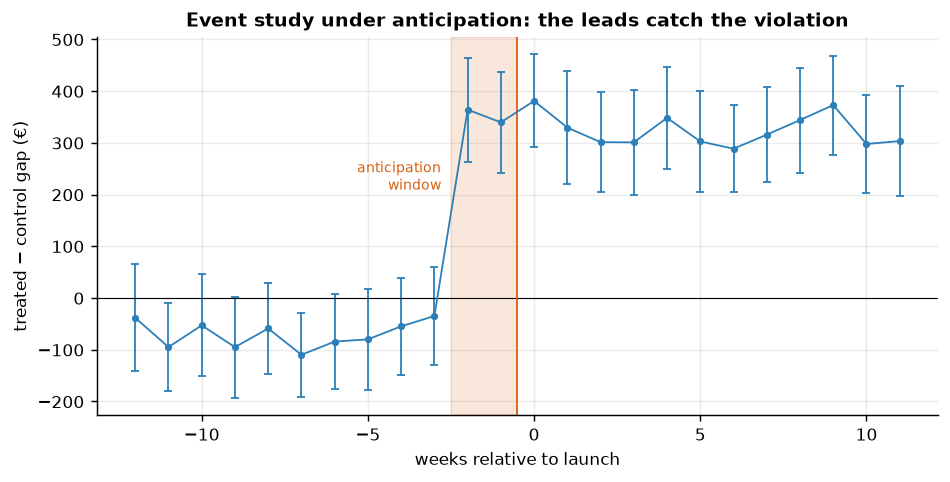

In [15]:
# Same DGP as Step 2, except the lift starts ANT weeks BEFORE the official launch (anticipation).
ANT = 2
rng_a = np.random.default_rng(SEED)
fx_a = rng_a.normal(1000, 150, 40)
tr_a = np.zeros(40, dtype=bool); tr_a[:20] = True; rng_a.shuffle(tr_a)
season_a = 60 * np.sin(2 * np.pi * np.arange(24) / 12)
rows_a = []
for s in range(40):
    eff = TRUE * (np.arange(24) >= LAUNCH - ANT) * tr_a[s]        # <- effect from week 10, not 12
    rows_a.append(pd.DataFrame({"unit": s, "t": np.arange(24), "group": int(tr_a[s]),
                                "post": (np.arange(24) >= LAUNCH).astype(int),
                                "revenue": fx_a[s] + season_a + eff + rng_a.normal(0, 80, 24)}))
da = pd.concat(rows_a, ignore_index=True)
piv_a = da.pivot_table(index="t", columns="group", values="revenue", aggfunc="mean")
sd_a  = da.pivot_table(index="t", columns="group", values="revenue", aggfunc="std")
n_a   = da.pivot_table(index="t", columns="group", values="revenue", aggfunc="count")
gap_a = piv_a[1] - piv_a[0]; se_a = np.sqrt(sd_a[1]**2 / n_a[1] + sd_a[0]**2 / n_a[0])
pre_a = gap_a.index < LAUNCH
gapc_a = gap_a - gap_a[pre_a].mean()
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.errorbar(gapc_a.index - LAUNCH, gapc_a.values, yerr=1.645 * se_a.values,
            color=plots.BLUE, marker="o", lw=1.0, ms=3, capsize=2)
ax.axvspan(-ANT - 0.5, -0.5, color=plots.ORANGE, alpha=0.15)
ax.text(-ANT - 0.8, gapc_a.max() * 0.55, "anticipation\nwindow", ha="right", fontsize=8, color=plots.ORANGE)
ax.axhline(0, color="k", lw=0.6); ax.axvline(-0.5, color=plots.ORANGE, lw=1)
ax.set_xlabel("weeks relative to launch"); ax.set_ylabel("treated − control gap (€)")
ax.set_title("Event study under anticipation: the leads catch the violation")
fig.tight_layout()
m_a = da.groupby(["group", "post"])["revenue"].mean()
did_a = (m_a[1, 1] - m_a[1, 0]) - (m_a[0, 1] - m_a[0, 0])
clean = da[(da.t < LAUNCH - ANT) | (da.t >= LAUNCH)]              # drop the contaminated pre-weeks
m_f = clean.groupby(["group", "post"])["revenue"].mean()
did_f = (m_f[1, 1] - m_f[1, 0]) - (m_f[0, 1] - m_f[0, 0])
n_bad = int((gapc_a[pre_a].abs() > 1.645 * se_a[pre_a]).sum())
print(f"The k=−2 and k=−1 leads sit at €{gapc_a.loc[LAUNCH - 2]:.0f} and €{gapc_a.loc[LAUNCH - 1]:.0f} — far outside "
      f"their 90% bands ({n_bad} of {int(pre_a.sum())} pre-launch leads exclude 0, vs ~1 expected by chance).")
print(f"Naive 2×2: €{did_a:.0f} vs true €{TRUE:.0f} — bias €{did_a - TRUE:+.0f}, ≈ −{ANT}/{LAUNCH} of the effect "
      f"(≈ €{TRUE * ANT / LAUNCH:.0f}): the {ANT} contaminated pre-weeks inflate the treated baseline by that much.")
print(f"Fix — drop the contaminated window from the pre-period: €{did_f:.0f}. "
      f"(Or define 'treatment' at the ANNOUNCEMENT date rather than the launch date.)")

**Read-out.** This is what a violated lead looks like — compare Step 3's clean version. The last two
leads jump out of their bands two weeks *before* the official launch, and because centred leads must
average zero by construction, the contamination also drags the *other* leads slightly negative: the
tell is a broken, tilted pre-period, not just two high dots. The flat-leads check is no formality — it
just caught a violation that quietly ate roughly a sixth of the measured effect. The remedies are cheap
once you *see* it: drop the anticipation window from the pre-period (done above — the estimate snaps
back to truth within noise) or date the treatment at *announcement* rather than launch. What the leads
still cannot do is certify PT itself: a time-varying, group-specific shock arriving exactly at launch
remains invisible.

**Trap 2 — staggered adoption.** Real chains rarely launch everywhere at once. With multiple adoption
dates the workhorse regression becomes static **two-way fixed effects (TWFE)**:

$$Y_{st}\;=\;\alpha_s+\lambda_t+\beta^{\text{TWFE}}\,D_{st}+\varepsilon_{st},\qquad D_{st}=\mathbf 1[t\ge g_s],$$

where $g_s$ is store $s$'s adoption week. **Goodman-Bacon (2021):** $\hat\beta^{\text{TWFE}}$ is a
variance-weighted average (each little 2×2 contributes a *weight* — its share of the final average;
normally weights are positive and sum to one) of **every pairwise 2×2 DiD** the panel contains — early-vs-late,
late-vs-early, treated-vs-untreated — *including* "forbidden comparisons" that use **already-treated**
cohorts as controls. When effects grow with time since adoption, those comparisons can receive
**negative weights**, so TWFE can land far from every true effect even though each one is positive.
Watch it happen:

Naive TWFE €177 vs true average post-treatment effect €400 — bias -223. Use Callaway–Sant'Anna / Sun–Abraham for staggered rollouts.


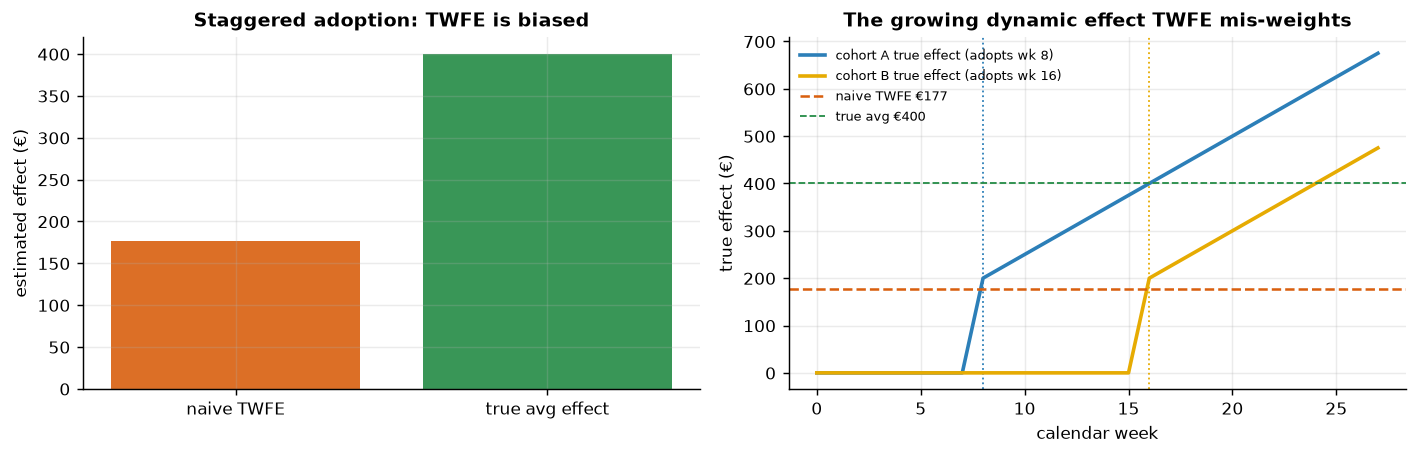

In [16]:
# staggered rollout: cohort A treated at week 8, cohort B at week 16, with a GROWING true effect
rng = np.random.default_rng(1); NS, NW = 60, 28
rows = []
for s in range(NS):
    cohort = "A" if s < NS//2 else "B"; g = 8 if cohort=="A" else 16
    base = rng.normal(1000, 120); season = 60*np.sin(2*np.pi*np.arange(NW)/12)
    # dynamic effect that GROWS after adoption (this is what breaks naive TWFE)
    te = np.where(np.arange(NW) >= g, 200 + 25*(np.arange(NW)-g), 0.0)
    rev = base + season + te + rng.normal(0, 60, NW)
    for t in range(NW):
        rows.append({"unit": s, "cohort": cohort, "t": t, "post": int(t>=g), "rev": rev[t], "true_te": te[t]})
sd = pd.DataFrame(rows)
# naive TWFE (single post dummy) vs the true average post-treatment effect
Xd = pd.get_dummies(sd["unit"], prefix="u").astype(float); Xt = pd.get_dummies(sd["t"], prefix="t").astype(float)
D = np.column_stack([np.ones(len(sd)), sd["post"].values, Xd.values[:,1:], Xt.values[:,1:]])
twfe = np.linalg.lstsq(D, sd["rev"].values, rcond=None)[0][1]
true_avg = sd.loc[sd.post==1, "true_te"].mean()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(["naive TWFE","true avg effect"], [twfe, true_avg], color=[plots.ORANGE, plots.GREEN], alpha=0.9)
ax[0].set_ylabel("estimated effect (€)"); ax[0].set_title("Staggered adoption: TWFE is biased")
# WHY it's biased: the true effect GROWS after each cohort adopts (weeks 8 and 16), so collapsing it
# to one post dummy — while using already-treated cohort A as a control for B — badly mis-weights it.
for _coh, _col in [("A", plots.BLUE), ("B", plots.GOLD)]:
    _g = 8 if _coh == "A" else 16
    _te = sd[sd.cohort == _coh].groupby("t")["true_te"].mean()
    ax[1].plot(_te.index, _te.values, color=_col, lw=2, label=f"cohort {_coh} true effect (adopts wk {_g})")
    ax[1].axvline(_g, color=_col, ls=":", lw=1)
ax[1].axhline(twfe, color=plots.ORANGE, ls="--", lw=1.4, label=f"naive TWFE €{twfe:.0f}")
ax[1].axhline(true_avg, color=plots.GREEN, ls="--", lw=1.0, label=f"true avg €{true_avg:.0f}")
ax[1].set_xlabel("calendar week"); ax[1].set_ylabel("true effect (€)")
ax[1].set_title("The growing dynamic effect TWFE mis-weights"); ax[1].legend(frameon=False, fontsize=7)
fig.tight_layout()
print(f"Naive TWFE €{twfe:.0f} vs true average post-treatment effect €{true_avg:.0f} — "
      f"bias {twfe-true_avg:+.0f}. Use Callaway–Sant'Anna / Sun–Abraham for staggered rollouts.")

**Why the bias is downward here — and the cure.** Cohort A adopts at week 8 and its effect keeps
*growing*; when B adopts at week 16, part of TWFE's estimate compares B against already-treated A — a
"control" whose revenue is still rising with A's growing effect. B's lift is measured against that
rising counterfactual and shrunk, and the growing tail of A's effect looks like a calendar trend that
the week effects $\lambda_t$ partially absorb. Net: the largest true effects get the smallest (even
negative) weights, and the estimate lands *below every single true post-adoption effect in the panel*.

The modern fix — **Callaway & Sant'Anna (2021)** — is a discipline, not a trick: *never use the
already-treated as controls*. Estimate one clean 2×2 per cohort $g$ and week $t$, anchored at the
cohort's last untreated week $g-1$, using only stores **not yet treated** at $t$ as controls:

$$\widehat{\text{ATT}}(g,t)\;=\;\big[\bar Y_{g,t}-\bar Y_{g,\,g-1}\big]\;-\;\big[\bar Y_{\mathcal C(t),\,t}-\bar Y_{\mathcal C(t),\,g-1}\big],\qquad \mathcal C(t)=\{s:\ g_s>t\},$$

then aggregate the cells (here a simple average — cohorts are equal-sized). One **design lesson** falls
straight out of the formula: in the two-cohort world above, $\mathcal C(t)$ is *empty* from week 16
onward — once everyone is treated there are no clean controls left and $\text{ATT}(g,t)$ simply does
not exist. Real rollouts should **keep a never-treated holdout** for exactly this reason. So we
regenerate the same growing-effect world with a third cohort C (20 stores, never treated) and run both
estimators on it — the ~15-line loop below is the entire method.

A never-treated holdout in the panel helps TWFE (€321 here vs €177 without one, above) but does NOT fix it — the forbidden A-as-control-for-B comparisons are still inside the average.
Hand-rolled Callaway–Sant'Anna: €405 vs true average €400 — within store-noise of the truth, from 32 clean (g,t) cells; the left panel shows the cells tracking the growing effect itself.
Production tools: R `did` (Callaway–Sant'Anna) or `fixest::sunab` (Sun–Abraham); Python `pyfixest`, `differences`.


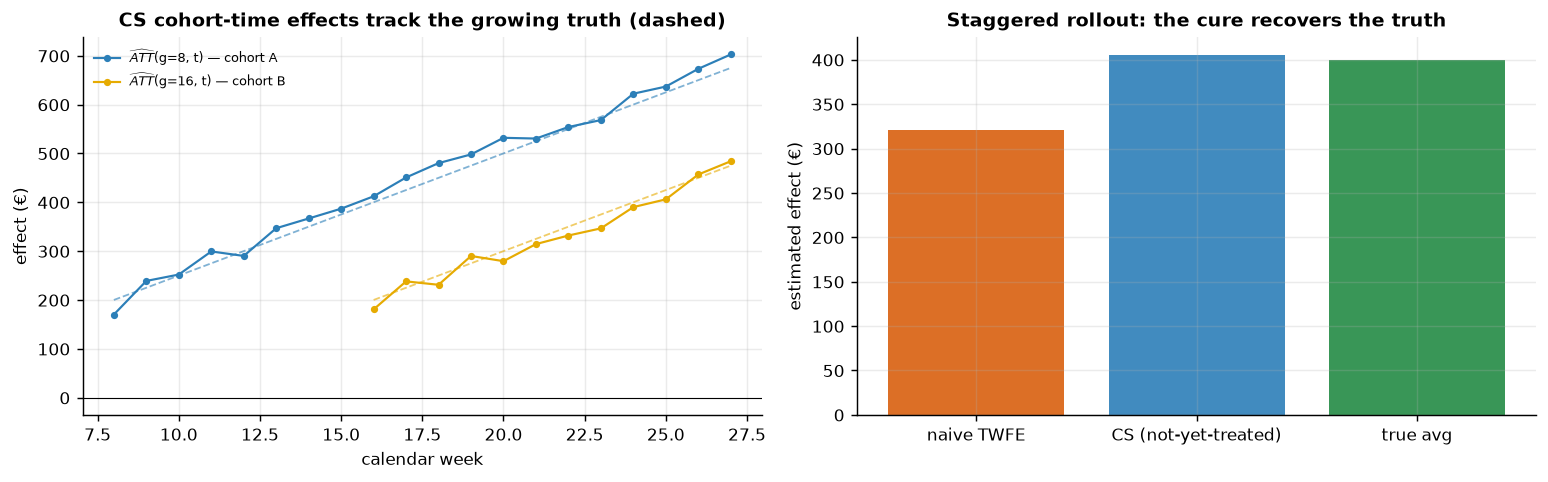

In [17]:
# Same growing-effect world + a never-treated cohort C, then: naive TWFE vs hand-rolled Callaway–Sant'Anna.
rng3 = np.random.default_rng(2); NW3 = 28
rows3 = []
for s in range(60):
    coh = "A" if s < 20 else ("B" if s < 40 else "C")
    g_s = {"A": 8, "B": 16, "C": 10**9}[coh]                     # cohort C: never treated ("adopts at infinity")
    base3 = rng3.normal(1000, 120); season3 = 60 * np.sin(2 * np.pi * np.arange(NW3) / 12)
    te3 = np.where(np.arange(NW3) >= g_s, 200 + 25 * (np.arange(NW3) - g_s), 0.0)
    rev3 = base3 + season3 + te3 + rng3.normal(0, 60, NW3)
    for t in range(NW3):
        rows3.append({"unit": s, "g": g_s, "t": t, "post": int(t >= g_s), "rev": rev3[t], "true_te": te3[t]})
s3 = pd.DataFrame(rows3)
# naive TWFE on the 3-cohort panel (the never-treated cohort now anchors the week effects)
X_u = pd.get_dummies(s3["unit"]).astype(float); X_t = pd.get_dummies(s3["t"]).astype(float)
D3 = np.column_stack([np.ones(len(s3)), s3["post"].values, X_u.values[:, 1:], X_t.values[:, 1:]])
twfe3 = np.linalg.lstsq(D3, s3["rev"].values, rcond=None)[0][1]
# Callaway–Sant'Anna by hand: one clean 2×2 per (cohort g, week t), controls = not-yet-treated at t
ym = s3.groupby(["g", "t"])["rev"].mean()
att = {}
for g in (8, 16):
    for t in range(g, NW3):
        ctrl3 = s3[s3.g > t]                                     # not-yet-treated at t (B early on, C always)
        att[(g, t)] = (ym[g, t] - ym[g, g - 1]) - (ctrl3[ctrl3.t == t]["rev"].mean()
                                                   - ctrl3[ctrl3.t == g - 1]["rev"].mean())
att = pd.Series(att); cs_avg = float(att.mean())
true_avg3 = s3.loc[s3.post == 1, "true_te"].mean()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for g, col, lab in [(8, plots.BLUE, "A"), (16, plots.GOLD, "B")]:
    tt = np.arange(g, NW3)
    ax[0].plot(tt, att.loc[g].values, "o-", color=col, ms=3, lw=1.2, label=f"$\\widehat{{ATT}}$(g={g}, t) — cohort {lab}")
    ax[0].plot(tt, 200 + 25 * (tt - g), ls="--", color=col, lw=1, alpha=0.6)
ax[0].axhline(0, color="k", lw=0.6); ax[0].set_xlabel("calendar week"); ax[0].set_ylabel("effect (€)")
ax[0].set_title("CS cohort-time effects track the growing truth (dashed)"); ax[0].legend(frameon=False, fontsize=7)
ax[1].bar(["naive TWFE", "CS (not-yet-treated)", "true avg"], [twfe3, cs_avg, true_avg3],
          color=[plots.ORANGE, plots.BLUE, plots.GREEN], alpha=0.9)
ax[1].set_ylabel("estimated effect (€)"); ax[1].set_title("Staggered rollout: the cure recovers the truth")
fig.tight_layout()
print(f"A never-treated holdout in the panel helps TWFE (€{twfe3:.0f} here vs €{twfe:.0f} without one, above) but "
      f"does NOT fix it — the forbidden A-as-control-for-B comparisons are still inside the average.")
print(f"Hand-rolled Callaway–Sant'Anna: €{cs_avg:.0f} vs true average €{true_avg3:.0f} — within store-noise of the "
      f"truth, from {len(att)} clean (g,t) cells; the left panel shows the cells tracking the growing effect itself.")
print("Production tools: R `did` (Callaway–Sant'Anna) or `fixest::sunab` (Sun–Abraham); Python `pyfixest`, `differences`.")

## 8 · What we tell the CMO

> **Finding.** The loyalty app lifted pilot-store revenue by ≈ €400/store/week net of the seasonal tide
> (Step 4's posterior — and the simulation's planted truth is €400, recovered). The estimate survived
> every falsification we threw at it: flat pre-launch leads (Step 3), a fake launch date (≈ 0, Step 5), a
> permutation of fake treated stores (the real estimate sits far outside anything store noise produced,
> 5b), a posterior predictive check (4b), and a multi-seed recovery loop (5c) — with the within-store
> design (5d) confirming the same point estimate under a far tighter, *calibrated* interval.
>
> **Decision.** At the €120/store/week running cost the base case says **ROLL OUT** (P(app pays) ≈ 1).
> But the DiD estimand is the **ATT — the effect on the pilot stores** — and the non-pilot stores need
> not respond identically, so the honest headline is the stress table's break-even band: the rollout
> clears its cost up to roughly **€300/store/week if the chain responds like the pilot, only ≈ €150 if
> half the lift transfers**. Hold the vendor quote against that band, not against the base-case annual
> € figure.
>
> **Recommended action.** Phase the rollout, with wave 2 in deliberately *non-pilot-like* stores to
> measure the transfer share directly — and keep a small **never-treated holdout** to the very end:
> Step 7 showed clean controls are what keep every later wave measurable, cheap insurance an
> all-at-once rollout destroys.
>
> **Watch-list** (the assumptions that carry everything): **parallel trends** — monitor the leads every
> wave; **no anticipation** — date effects from *announcement* and drop contaminated pre-weeks (the
> leads catch it, as demonstrated); **no cross-store spillover** — flag pilot stores sharing a
> catchment with controls; and **never evaluate a staggered rollout with a single post dummy** — use
> cohort-time effects with not-yet-treated controls (Callaway–Sant'Anna), or growing effects will bias
> the answer just as TWFE's did above.

**Method summary.** DiD buys identification with two assumptions (PT + NA) and one subtraction; the
event-study leads probe NA and make PT credible, but nothing certifies PT post-launch. Step 0's classical
read — a 2×2 OLS with store-clustered errors — reaches the same number, and (see 5x) the same honest
width: the causal content is in the identification, and the Bayesian layer earns its keep at the
*decision*, by turning that estimate into P(lift > cost). The Bayesian
layer is ordinary regression — the craft is in the *scale* (default priors vs euro data, Step 4), in
the *collapse* that guards against serial correlation (BDM), and in knowing which residual your
interval is paying for (5b–5d). **On real data:** notebook 07b (geo-lift on a real Google
geo-experiment) is this design's nearest real-data sibling in the cookbook, and Card & Krueger (1994)
remains the classic public DiD panel to practice on.

---
## Book export

The book chapter built from this notebook (`book/chapters/did.tex`) does not retype a single
number. Every figure it prints — every euro amount, standard error, coverage rate, table cell and
plot — is *emitted* below by `cmp.report` into `book/build/results/nb08.json`, from which
`book/build.py` generates `macros.tex`, the booktabs tables and the vector figures the chapter
`\input`s. A number that goes stale is impossible; a number that goes *missing* is a LaTeX compile
error rather than a silent hole. The cell adds no output of its own — the notebook above is
unchanged.


In [18]:
# ---------------------------------------------------------------- Book export (cmp.report)
# The book chapter (book/chapters/did.tex) never retypes a number: every figure it prints is
# emitted HERE, from this executed run, into book/build/results/nb08.json -> macros.tex (see
# src/cmp/report.py). A missing macro is a LaTeX compile error, never a silent hole. Figures are
# re-rendered in book style (vector PDF, no in-figure title — the caption does that work) and
# closed immediately, so this cell changes nothing the notebook shows above.
import matplotlib as mpl
from cmp import report as R

def V(k, v, **kw):
    return R.value(f"nb08.{k}", v, **kw)

# --- the world, and the planted truth -------------------------------------------------
V("n_stores", int(df["unit"].nunique()), fmt="d")
V("n_weeks", int(df["t"].nunique()), fmt="d")
V("n_obs", int(len(df)), fmt="d")
V("launch", int(LAUNCH), fmt="d")
V("n_pre", int(LAUNCH), fmt="d")
V("n_post", int(df["t"].nunique() - LAUNCH), fmt="d")
V("n_treated", int(df.groupby("unit")["group"].first().sum()), fmt="d")
V("true_effect", float(true_effect), unit="EUR", fmt=".0f")
V("alpha_sd", 150, fmt="d", note="sd of the store baseline alpha_s, by construction")
V("noise_sd", 80, fmt="d", note="sd of the weekly idiosyncratic shock")
V("season_amp", 60, fmt="d", note="amplitude of the shared seasonal wave")
V("seed", int(SEED), fmt="d")

# --- Step 0 · the classical arm --------------------------------------------------------
V("att_cl", att_cluster.estimate, unit="EUR", fmt=".0f")
V("att_cl_lo", att_cluster.ci[0], unit="EUR", fmt=".0f")
V("att_cl_hi", att_cluster.ci[1], unit="EUR", fmt=".0f")
V("att_cl_se", att_cluster.se, unit="EUR", fmt=".1f")
V("att_cl_half", (att_cluster.ci[1] - att_cluster.ci[0]) / 2, unit="EUR", fmt=".0f")
V("att_cl_err", att_cluster.estimate - true_effect, unit="EUR", fmt="+.0f")
V("att_cl_err_abs", abs(att_cluster.estimate - true_effect), unit="EUR", fmt=".0f")
V("n_clusters", int(att_cluster.extra["n_clusters"]), fmt="d")
V("att_iid_se", att_iid.se, unit="EUR", fmt=".1f")
V("att_iid_lo", att_iid.ci[0], unit="EUR", fmt=".0f")
V("att_iid_hi", att_iid.ci[1], unit="EUR", fmt=".0f")
V("att_iid_half", (att_iid.ci[1] - att_iid.ci[0]) / 2, unit="EUR", fmt=".0f")
V("se_ratio_did", att_cluster.se / att_iid.se, fmt=".2f")
V("se_shrink_did", att_iid.se / att_cluster.se, fmt=".1f")
V("lvl_iid_se", lvl_iid.se, unit="EUR", fmt=".1f")
V("lvl_cls_se", lvl_cls.se, unit="EUR", fmt=".1f")
V("se_ratio_level", lvl_cls.se / lvl_iid.se, fmt=".1f")
V("lvl_est", lvl_iid.estimate, unit="EUR", fmt=".0f")

# --- the AR(1) sweep: BDM's own mechanism, isolated ------------------------------------
# Recomputed here from the SAME `ar1_panel` and the SAME seeds as the cell above, so the table
# and the printed sweep are the same numbers by construction.
_rhos = (0.0, 0.5, 0.8, 0.95)
_ar1 = []
for _rho in _rhos:
    _sc, _si = [], []
    for _sd in range(10):
        _p = ar1_panel(_rho, seed=200 + _sd)
        _sc.append(cl.did_2x2(_p, outcome="revenue", unit="unit", time="t",
                              treated="group", post="post").se)
        _si.append(cl.ols(_p.rename(columns={"revenue": "_y", "group": "_g", "post": "_p"}),
                          "_y ~ _g*_p", target="_g:_p", cov="nonrobust").se)
    _ar1.append({"rho": _rho, "se_c": float(np.mean(_sc)), "se_i": float(np.mean(_si))})
ar1_df = pd.DataFrame(_ar1)
V("arone_se_zero", float(ar1_df.se_c[ar1_df.rho == 0.0].iloc[0]), unit="EUR", fmt=".1f")
V("arone_se_peak", float(ar1_df.se_c.max()), unit="EUR", fmt=".1f")
V("arone_rho_peak", float(ar1_df.rho[ar1_df.se_c.idxmax()]), fmt=".2f")
V("arone_se_top", float(ar1_df.se_c.iloc[-1]), unit="EUR", fmt=".1f")
V("arone_rho_top", float(ar1_df.rho.iloc[-1]), fmt=".2f")
V("arone_se_growth", float(ar1_df.se_c.max() / ar1_df.se_c[ar1_df.rho == 0.0].iloc[0]), fmt=".1f")
V("arone_iid_spread", float(ar1_df.se_i.max() - ar1_df.se_i.min()), unit="EUR", fmt=".1f")
V("arone_n_panels", 10, fmt="d")

# --- the event study -------------------------------------------------------------------
_leads = es[(es["k"] < 0) & (~es["is_base"])]
_lags = es[es["k"] >= 0]
V("es_n_leads", int(len(_leads)), fmt="d")
V("es_n_pre", int((es["k"] < 0).sum()), fmt="d")
V("es_leads_out", int(((_leads["lo"] > 0) | (_leads["hi"] < 0)).sum()), fmt="d")
V("es_mean_abs_lead", float(_leads["estimate"].abs().mean()), unit="EUR", fmt=".0f")
V("es_lead_se", float(_leads["se"].mean()), unit="EUR", fmt=".0f")
V("es_n_lags", int(len(_lags)), fmt="d")
V("es_lag_mean", float(_lags["estimate"].mean()), unit="EUR", fmt=".0f")
V("es_lag_min", float(_lags["estimate"].min()), unit="EUR", fmt=".0f")
V("es_lag_max", float(_lags["estimate"].max()), unit="EUR", fmt=".0f")
V("es_lag_vs_did", abs(float(_lags["estimate"].mean()) - att_cluster.estimate), unit="EUR", fmt=".0f")

# --- §4 · the pooled Bayesian 2x2 ------------------------------------------------------
_conv = est.convergence_report(result.idata)
V("bayes_att", float(impact.mean()), unit="EUR", fmt=".0f")
V("bayes_lo", float(np.quantile(impact, 0.05)), unit="EUR", fmt=".0f")
V("bayes_hi", float(np.quantile(impact, 0.95)), unit="EUR", fmt=".0f")
V("bayes_half", float(np.quantile(impact, 0.95) - np.quantile(impact, 0.05)) / 2, unit="EUR", fmt=".0f")
V("bayes_rhat", _conv["max_rhat"], fmt=".3f")
V("bayes_ess", _conv["min_ess_bulk"], fmt=",.0f")
V("bayes_div", int(_conv["n_divergences"]), fmt="d")
V("bayes_sigma", float(sig_eur), unit="EUR", fmt=".0f")
V("ppc_cov", 100 * float(cov_ppc), fmt=".0f")
V("n_collapsed", int(len(agg)), fmt="d")

# --- §5 · validation -------------------------------------------------------------------
V("did_hand", float(did_2x2), unit="EUR", fmt=".0f")
V("placebo_time", float(placebo), unit="EUR", fmt=".0f")
V("placebo_time_se", float(placebo_se), unit="EUR", fmt=".0f")
V("placebo_time_week", 6, fmt="d")
V("perm_n", int(NPERM), fmt="d")
V("perm_sd", float(perm.std()), unit="EUR", fmt=".0f")
V("perm_max", float(np.abs(perm).max()), unit="EUR", fmt=".0f")
V("perm_p", float(p_perm), fmt=".3f")
V("perm_z", abs(float(impact.mean())) / float(perm.std()), fmt=".0f")
V("perm_two_sd", 2 * float(perm.std()), unit="EUR", fmt=".0f")
V("seed_n", int(NSEED), fmt="d")
V("seed_mean", float(pts.mean()), unit="EUR", fmt=".0f")
V("seed_bias", float(pts.mean() - true_effect), unit="EUR", fmt="+.0f")
V("seed_bias_abs", abs(float(pts.mean() - true_effect)), unit="EUR", fmt=".0f")
V("seed_sd", float(pts.std()), unit="EUR", fmt=".0f")
V("seed_cov", int(cov), fmt="d")
V("pooled_over_scatter", float(half) / float(pts.std()), fmt=".0f")

# --- 5d · within-store differencing ----------------------------------------------------
_conv_fe = est.convergence_report(idata_fe)
V("fe_att", float(impact_fe.mean()), unit="EUR", fmt=".0f")
V("fe_lo", float(q_f[0]), unit="EUR", fmt=".0f")
V("fe_hi", float(q_f[1]), unit="EUR", fmt=".0f")
V("fe_half", float(half_f), unit="EUR", fmt=".0f")
V("fe_tighter", float(half_w / half_f), fmt=".0f")
V("fe_rhat", _conv_fe["max_rhat"], fmt=".3f")
V("fe_ess", _conv_fe["min_ess_bulk"], fmt=",.0f")
V("fe_div", int(_conv_fe["n_divergences"]), fmt="d")
V("fe_seed_mean", float(pts_fe.mean()), unit="EUR", fmt=".0f")
V("fe_seed_sd", float(pts_fe.std()), unit="EUR", fmt=".0f")
V("fe_cov", int(cov_fe), fmt="d")
V("fe_hw_over_scatter", float(np.mean(hw_fe) / pts_fe.std()), fmt=".1f")
V("calibrated_ratio", 1.6, fmt=".1f", note="half-width / sampling sd of a calibrated 90% interval")

# --- 5x · the five-way comparison ------------------------------------------------------
# Rebuilt here rather than reusing 5x's `rows`, which the staggered-adoption cell overwrites.
_rows = [("Classical two-by-two, iid SE (wrong)",     att_iid.estimate,     *att_iid.ci,     None),
         ("Classical two-by-two, clustered on store", att_cluster.estimate, *att_cluster.ci, None),
         ("Classical within-store change, HC1",       att_delta.estimate,   *att_delta.ci,   None),
         ("Bayesian pooled two-by-two (CausalPy)",    float(impact.mean()),
          *np.quantile(impact, [.05, .95]), impact),
         ("Bayesian within-store change (PyMC)",      float(impact_fe.mean()),
          *np.quantile(impact_fe, [.05, .95]), impact_fe)]
_ests = [r[1] for r in _rows]
V("att_delta", att_delta.estimate, unit="EUR", fmt=".0f")
V("att_delta_lo", att_delta.ci[0], unit="EUR", fmt=".0f")
V("att_delta_hi", att_delta.ci[1], unit="EUR", fmt=".0f")
V("att_delta_half", (att_delta.ci[1] - att_delta.ci[0]) / 2, unit="EUR", fmt=".0f")
V("est_span", float(max(_ests) - min(_ests)), unit="EUR", fmt=".0f")
V("est_span_pct", 100 * float(max(_ests) - min(_ests)) / true_effect, fmt=".0f")
V("est_lo", float(min(_ests)), unit="EUR", fmt=".0f")
V("est_hi", float(max(_ests)), unit="EUR", fmt=".0f")
V("bayes_over_cluster", float(half_w / ((att_cluster.ci[1] - att_cluster.ci[0]) / 2)), fmt=".0f")

# --- §6 · the euro decision ------------------------------------------------------------
V("app_cost", float(APP_COST), unit="EUR", fmt=".0f")
V("n_chain", int(N_STORES), fmt="d")
V("weeks_year", int(WEEKS), fmt="d")
V("net_mean", float(net.mean()), unit="EUR", fmt=".0f")
V("annual_mean", float(annual.mean()), unit="EUR", fmt=",.0f")
V("annual_lo", float(np.quantile(annual, 0.05)), unit="EUR", fmt=",.0f")
V("annual_hi", float(np.quantile(annual, 0.95)), unit="EUR", fmt=",.0f")
V("annual_mean_m", float(annual.mean()) / 1e6, unit="EURm", fmt=".1f")
V("annual_lo_m", float(np.quantile(annual, 0.05)) / 1e6, unit="EURm", fmt=".1f")
V("annual_hi_m", float(np.quantile(annual, 0.95)) / 1e6, unit="EURm", fmt=".1f")
V("p_pays", float(p_worth), fmt=".2f")
V("decision", "ROLL OUT" if p_worth > 0.9 else "pilot further")
V("break_even", float(be95), unit="EUR", fmt=".0f")
V("break_even_fe", float(q_f[0]), unit="EUR", fmt=".0f")
V("cap_full", float(np.quantile(impact, 0.10)), unit="EUR", fmt=".0f")
V("cap_three_quarter", float(np.quantile(impact * 0.75, 0.10)), unit="EUR", fmt=".0f")
V("cap_half", float(np.quantile(impact * 0.50, 0.10)), unit="EUR", fmt=".0f")
V("p_half_cost_mid", float((impact * 0.50 > 200).mean()), fmt=".2f")
V("p_half_cost_high", float((impact * 0.50 > 300).mean()), fmt=".2f")
V("p_full_cost_high", float((impact > 300).mean()), fmt=".2f")
V("p_pooled_near_att", float((impact > 380).mean()), fmt=".2f")
V("p_fe_near_att", float((impact_fe > 380).mean()), fmt=".2f")
V("cost_low", float(costgrid[0]), unit="EUR", fmt=".0f")
V("cost_mid", float(costgrid[2]), unit="EUR", fmt=".0f")
V("cost_high", float(costgrid[3]), unit="EUR", fmt=".0f")
V("cost_near_att", 380.0, unit="EUR", fmt=".0f", note="a stress cost just below the estimated ATT")

# --- §7 · what can go wrong ------------------------------------------------------------
V("ant_weeks", int(ANT), fmt="d")
V("ant_lead_minus_two", float(gapc_a.loc[LAUNCH - 2]), unit="EUR", fmt=".0f")
V("ant_lead_minus_one", float(gapc_a.loc[LAUNCH - 1]), unit="EUR", fmt=".0f")
V("ant_leads_out", int(n_bad), fmt="d")
V("ant_did", float(did_a), unit="EUR", fmt=".0f")
V("ant_bias", float(did_a - TRUE), unit="EUR", fmt="+.0f")
V("ant_bias_abs", abs(float(did_a - TRUE)), unit="EUR", fmt=".0f")
V("ant_fixed", float(did_f), unit="EUR", fmt=".0f")
V("twfe_naive", float(twfe), unit="EUR", fmt=".0f")
V("twfe_true", float(true_avg), unit="EUR", fmt=".0f")
V("twfe_bias", float(twfe - true_avg), unit="EUR", fmt="+.0f")
V("twfe_bias_abs", abs(float(twfe - true_avg)), unit="EUR", fmt=".0f")
V("twfe_holdout", float(twfe3), unit="EUR", fmt=".0f")
V("cs_att", float(cs_avg), unit="EUR", fmt=".0f")
V("cs_true", float(true_avg3), unit="EUR", fmt=".0f")
V("cs_err", float(cs_avg - true_avg3), unit="EUR", fmt="+.0f")
V("cs_err_abs", abs(float(cs_avg - true_avg3)), unit="EUR", fmt=".0f")
V("cs_cells", int(len(att)), fmt="d")
V("stag_n_stores", 60, fmt="d")
V("stag_cohort_a", 8, fmt="d")
V("stag_cohort_b", 16, fmt="d")
V("stag_base", 200, fmt="d")
V("stag_growth", 25, fmt="d")

# --- tables ----------------------------------------------------------------------------
R.table(pd.DataFrame([
    {"Contrast (one and the same fit)": "ATT: the group-by-post interaction",
     "iid SE": f"{att_iid.se:.1f}", "Clustered SE": f"{att_cluster.se:.1f}",
     "Clustered / iid": f"{att_cluster.se / att_iid.se:.2f}",
     "The iid SE was": "too WIDE"},
    {"Contrast (one and the same fit)": "Level gap: the coefficient on group",
     "iid SE": f"{lvl_iid.se:.1f}", "Clustered SE": f"{lvl_cls.se:.1f}",
     "Clustered / iid": f"{lvl_cls.se / lvl_iid.se:.2f}",
     "The iid SE was": "too NARROW"},
]), "nb08.se", align="lrrrl",
    caption=(f"Two coefficients of the \\emph{{same}} regression, and two standard errors each "
             f"(€/store/week; {len(df):,} store-weeks, {att_cluster.extra['n_clusters']} stores). "
             f"The point estimates are unaffected by the covariance choice: the interaction is "
             f"€{att_cluster.estimate:.0f} and the level gap €{lvl_iid.estimate:.0f} either way. "
             f"Clustering on store \\emph{{shrinks}} the standard error of the DiD interaction by a "
             f"factor of {att_iid.se / att_cluster.se:.1f} and \\emph{{inflates}} the standard error "
             f"of the level gap by a factor of {lvl_cls.se / lvl_iid.se:.1f}. The iid formula is "
             f"neither conservative nor anti-conservative: it is wrong in a direction that flips "
             f"between two coefficients of one fit."),
    label="tab:did:se")

R.table(pd.DataFrame([
    {"AR(1) persistence $\\rho$": f"{r.rho:.2f}",
     "Clustered SE": f"{r.se_c:.1f}",
     "iid SE": f"{r.se_i:.1f}",
     "Clustered / iid": f"{r.se_c / r.se_i:.2f}"}
    for r in ar1_df.itertuples()
]), "nb08.arone", align="lrrr", math_headers=True,
    caption=(f"Bertrand--Duflo--Mullainathan's own mechanism, isolated. The identical panel and the "
             f"identical estimator, with only the weekly shocks made serially correlated at "
             f"persistence $\\rho$ (marginal sd held at €80); each row averages 10 fresh panels. The "
             f"clustered standard error --- the honest one --- climbs from €"
             f"{ar1_df.se_c.iloc[0]:.1f} to €{ar1_df.se_c.max():.1f} and then \\emph{{eases}} at "
             f"$\\rho = {ar1_df.rho.iloc[-1]:.2f}$: a near-permanent shock behaves like a store "
             f"baseline and differences out, so it is \\emph{{intermediate}} persistence that does the "
             f"most damage. The iid standard error moves by €{ar1_df.se_i.max() - ar1_df.se_i.min():.1f} "
             f"across the whole sweep --- serial correlation does not appear in its formula at all."),
    label="tab:did:arone")

R.table(pd.DataFrame([
    {"Estimator": lab, "Est.": f"{e:.0f}", "5\\%": f"{lo:.0f}", "95\\%": f"{hi:.0f}",
     "$\\pm$ half": f"{(hi - lo) / 2:.0f}",
     "$P(\\mathrm{ATT} > 120)$": ("not defined" if draws is None
                                   else f"{(draws > APP_COST).mean():.2f}")}
    for lab, e, lo, hi, draws in _rows
]), "nb08.compare", align="lrrrrr", math_headers=True,
    caption=(f"One estimand (the ATT), one identification (parallel trends + no anticipation), five "
             f"intervals (€/store/week; planted truth €{true_effect:.0f}). The point estimates span "
             f"€{max(_ests) - min(_ests):.0f} --- {100 * (max(_ests) - min(_ests)) / true_effect:.0f}\\,\\% "
             f"of the effect --- and every interval covers the truth. The widths do not agree: the "
             f"pooled Bayesian 2$\\times$2 is {half_w / ((att_cluster.ci[1] - att_cluster.ci[0]) / 2):.0f}"
             f"$\\times$ wider than the clustered classical interval, and the last column holds the one "
             f"quantity the classical arm cannot produce at any level of effort."),
    label="tab:did:compare")

R.table(pd.DataFrame([
    {"Transfer share": lab,
     **{f"€{c}": f"{(impact * tr > c).mean():.2f}" for c in costgrid}}
    for tr, lab in transfers
]), "nb08.stress", align="lrrrr",
    caption=(f"$P(\\text{{the app pays}})$ across the two things the pilot did not measure: the running "
             f"cost per store-week (columns) and the share of the pilot lift the other "
             f"{N_STORES - int(df.groupby('unit')['group'].first().sum())} stores realise (rows). Read "
             f"\\emph{{across}} a row and the call barely moves; read \\emph{{down}} a column and it "
             f"collapses. The transfer assumption, not the vendor's price, is what the rollout decision "
             f"turns on --- and the pilot contains no information about it."),
    label="tab:did:stress")

R.table(pd.DataFrame([
    {"Estimator": "Naive TWFE, no never-treated cohort", "Estimate": f"{twfe:.0f}",
     "Error vs the truth": f"{twfe - true_avg:+.0f}"},
    {"Estimator": "Naive TWFE, with a never-treated cohort", "Estimate": f"{twfe3:.0f}",
     "Error vs the truth": f"{twfe3 - true_avg3:+.0f}"},
    {"Estimator": "Callaway--Sant'Anna (not-yet-treated controls)", "Estimate": f"{cs_avg:.0f}",
     "Error vs the truth": f"{cs_avg - true_avg3:+.0f}"},
    {"Estimator": "True average post-adoption effect", "Estimate": f"{true_avg3:.0f}",
     "Error vs the truth": "--"},
]), "nb08.staggered", align="lrr",
    caption=(f"The two-way fixed-effects trap, and the cure (€/store/week). Two cohorts adopt at weeks "
             f"8 and 16 and the true effect \\emph{{grows}} after adoption. A single post dummy lands at "
             f"€{twfe:.0f} against a true average of €{true_avg:.0f} --- below \\emph{{every}} true "
             f"post-adoption effect in the panel, because the forbidden comparisons that use "
             f"already-treated cohorts as controls carry negative weight. A never-treated holdout helps "
             f"but does not cure it. Estimating one clean 2$\\times$2 per cohort-week against only "
             f"not-yet-treated controls recovers €{cs_avg:.0f} from {len(att)} cells."),
    label="tab:did:staggered")

# --- figures (book style: vector PDF, no in-figure title, closed so nothing renders inline) ---
with mpl.rc_context(R.book_style()):
    _g = df.groupby(["t", "group"])["revenue"].mean().unstack()
    f = plt.figure(figsize=(6.6, 3.2)); a = f.add_subplot(111)
    a.plot(_g.index, _g[1], color=plots.BLUE, lw=1.8, label="pilot stores (treated)")
    a.plot(_g.index, _g[0], color=plots.ORANGE, lw=1.8, label="control stores")
    a.axvline(LAUNCH, color="k", ls=":", lw=1.2)
    a.text(LAUNCH + 0.2, _g.values.min(), " launch", fontsize=9)
    a.set_xlabel("week"); a.set_ylabel("mean revenue (€/store/week)")
    a.legend(frameon=False)
    f.tight_layout()
    R.figure(f, "nb08.panel", caption=(
        f"The panel: mean weekly revenue in the {int(df.groupby('unit')['group'].first().sum())} pilot "
        f"stores and the {int((~df.groupby('unit')['group'].first().astype(bool)).sum())} controls. Both "
        f"groups ride the same seasonal wave, which is why a before-and-after comparison inside the "
        f"pilot stores would book the tide as app effect. The pilot stores also sit at a different "
        f"\\emph{{level}} --- and difference-in-differences does not care, because a time-invariant "
        f"baseline cancels in the contrast."), label="fig:did:panel")
    plt.close(f)

    f = plt.figure(figsize=(6.8, 3.6)); a = f.add_subplot(111)
    plots.event_study_plot(a, es["k"], es["estimate"], es["lo"], es["hi"], launch=0)
    a.axhline(true_effect, color=plots.GREEN, ls="--", lw=0.9)
    a.text(-12.4, true_effect + 16, f"planted €{true_effect:.0f}", fontsize=9, color=plots.GREEN)
    a.scatter([-1], [0], s=44, facecolors="none", edgecolors="k", zorder=5)
    a.annotate("$k = -1$: the reference\nweek, pinned to zero\nby construction",
               xy=(-1, 0), xytext=(-10.5, 250), fontsize=8,
               arrowprops=dict(arrowstyle="->", lw=0.7, color="k"))
    a.set_ylabel("effect vs the $k = -1$ week (€)")
    f.tight_layout()
    R.figure(f, "nb08.eventstudy", caption=(
        f"The single most important plot in a difference-in-differences analysis, and the only evidence "
        f"for parallel trends anyone will ever have. Two-way fixed-effects coefficients by week relative "
        f"to launch, with store-clustered 90\\,\\% intervals. There are {int((es['k'] < 0).sum())} "
        f"pre-launch weeks but only {len(_leads)} \\emph{{leads}}: $k = -1$ is spent as the reference "
        f"category and is zero \\emph{{by construction}}, not by evidence --- a point readers routinely "
        f"misread as a finding. Of the {len(_leads)} free leads, {int(((_leads['lo'] > 0) | (_leads['hi'] < 0)).sum())} "
        f"exclude zero, where 90\\,\\% intervals would put roughly one there by chance. The effect then "
        f"steps immediately to a mean of €{_lags['estimate'].mean():.0f} and stays flat: no build-up, "
        f"no decay."), label="fig:did:eventstudy")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    plots.ppc_plot(a, y_obs, y_rep)
    a.set_xlabel("store-period mean revenue (€)")
    f.tight_layout()
    R.figure(f, "nb08.ppc", caption=(
        f"Posterior predictive check on the pooled 2$\\times$2 model: {len(agg)} replicated store-period "
        f"revenues (thin) against the observed ones (heavy). {100 * cov_ppc:.0f}\\,\\% of the observations "
        f"fall inside their 5--95\\,\\% replicate band, so the model can generate data like this. Note "
        f"\\emph{{how}} it manages: a residual $\\sigma$ of €{sig_eur:.0f}, fat enough to swallow the "
        f"between-store baseline scatter (sd €150 by construction) that four cell means do not describe. "
        f"That same fat $\\sigma$ is what makes the effect interval "
        f"{half_w / ((att_cluster.ci[1] - att_cluster.ci[0]) / 2):.0f}$\\times$ too wide."),
        label="fig:did:ppc")
    plt.close(f)

    f = plt.figure(figsize=(6.8, 2.7)); a = f.add_subplot(111)
    plots.forest_plot(a, [r[0] for r in _rows], [r[1] for r in _rows],
                      [r[2] for r in _rows], [r[3] for r in _rows],
                      ref=true_effect, xlabel="ATT (€/store/week)")
    f.tight_layout()
    R.figure(f, "nb08.forest", caption=(
        f"One estimand, five intervals (planted truth dashed). Every arm agrees on the number to within "
        f"€{max(_ests) - min(_ests):.0f}; only the widths disagree. The clustered classical interval and "
        f"the within-store posterior land on the same scale, and the pooled Bayesian 2$\\times$2 --- the "
        f"one model that leaves the store baselines in $\\sigma$ --- is the outlier."),
        label="fig:did:forest")
    plt.close(f)

    f = plt.figure(figsize=(6.8, 3.2)); a = f.add_subplot(111)
    a.hist(perm, bins=30, color=plots.GREY, alpha=0.9,
           label=f"{NPERM} relabellings of the {int((~df.groupby('unit')['group'].first().astype(bool)).sum())} control stores")
    a.axvline(float(impact.mean()), color=plots.BLUE, lw=1.8,
              label=f"the real estimate €{impact.mean():.0f}")
    a.set_xlim(min(perm.min() * 1.3, -60), float(impact.mean()) * 1.12)
    a.set_xlabel("placebo DiD (€/store/week)"); a.set_ylabel("relabellings")
    a.legend(frameon=False)
    f.tight_layout()
    R.figure(f, "nb08.permutation", caption=(
        f"Placebo-in-group: the same 2$\\times$2, run on {NPERM} random relabellings of the control "
        f"stores alone, where the true effect is exactly zero. Store noise moves this estimator by a "
        f"standard deviation of €{perm.std():.0f} and never further than €{np.abs(perm).max():.0f}; the "
        f"real estimate sits {abs(float(impact.mean())) / float(perm.std()):.0f} null standard "
        f"deviations away ($p \\le {p_perm:.3f}$, the resolution floor of {NPERM} draws). This is also "
        f"an assumption-light reading of the estimator's true scale --- and it is nowhere near the "
        f"pooled posterior's $\\pm$€{half_w:.0f}."), label="fig:did:permutation")
    plt.close(f)

    f = plt.figure(figsize=(6.8, 3.4)); a = f.add_subplot(111)
    a.errorbar(gapc_a.index - LAUNCH, gapc_a.values, yerr=1.645 * se_a.values,
               color=plots.BLUE, marker="o", lw=1.0, ms=3, capsize=2)
    a.axvspan(-ANT - 0.5, -0.5, color=plots.ORANGE, alpha=0.15)
    a.text(-ANT - 0.8, gapc_a.max() * 0.55, "anticipation\nwindow", ha="right", fontsize=9,
           color=plots.ORANGE)
    a.axhline(0, color="k", lw=0.6); a.axvline(-0.5, color=plots.ORANGE, lw=1)
    a.set_xlabel("weeks relative to launch"); a.set_ylabel("treated $-$ control gap (€)")
    f.tight_layout()
    R.figure(f, "nb08.anticipation", caption=(
        f"No anticipation, broken on purpose: the lift starts {ANT} weeks before the official launch. "
        f"The last two leads jump to €{gapc_a.loc[LAUNCH - 2]:.0f} and €{gapc_a.loc[LAUNCH - 1]:.0f}, "
        f"far outside their bands, and because centred leads must average zero the contamination tilts "
        f"the \\emph{{other}} leads negative too --- {n_bad} of {int(pre_a.sum())} pre-launch leads now "
        f"exclude zero. The 2$\\times$2 subtracts part of the app from itself and reports €{did_a:.0f} "
        f"against a true €{TRUE:.0f}. Dropping the contaminated window restores €{did_f:.0f}."),
        label="fig:did:anticipation")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 3.2)); ax2 = f.subplots(1, 2)
    for _g_, _col, _lab in [(8, plots.BLUE, "A"), (16, plots.GOLD, "B")]:
        _tt = np.arange(_g_, NW3)
        ax2[0].plot(_tt, att.loc[_g_].values, "o-", color=_col, ms=3, lw=1.2,
                    label=f"$\\widehat{{ATT}}(g={_g_},t)$ — cohort {_lab}")
        ax2[0].plot(_tt, 200 + 25 * (_tt - _g_), ls="--", color=_col, lw=1, alpha=0.6)
    ax2[0].axhline(0, color="k", lw=0.6)
    ax2[0].set_xlabel("calendar week"); ax2[0].set_ylabel("effect (€)")
    ax2[0].legend(frameon=False, fontsize=8)
    ax2[1].bar(["naive\nTWFE", "Callaway–\nSant'Anna", "true\naverage"],
               [twfe3, cs_avg, true_avg3], color=[plots.ORANGE, plots.BLUE, plots.GREEN], alpha=0.9)
    ax2[1].set_ylabel("estimated effect (€)")
    f.tight_layout()
    R.figure(f, "nb08.cohorts", caption=(
        f"Staggered adoption. \\emph{{Left}}: Callaway--Sant'Anna's cohort-time effects (solid) track "
        f"the growing true effect (dashed) for both cohorts, because each cell compares a cohort against "
        f"stores \\emph{{not yet treated}} at that week. \\emph{{Right}}: on the same panel, a single "
        f"post dummy returns €{twfe3:.0f} against a true average of €{true_avg3:.0f}, while aggregating "
        f"the clean cells returns €{cs_avg:.0f}. Nothing in the TWFE output announces the problem --- "
        f"which is why the fix is a discipline, not a diagnostic."), label="fig:did:staggered")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 3.1)); ax2 = f.subplots(1, 2)
    plots.decision_hist(ax2[0], impact, APP_COST, true_total=true_effect)
    ax2[0].set_xlabel("ATT (€/store/week)"); ax2[0].set_ylabel("posterior draws")
    _cgrid = np.linspace(0, 500, 120)
    for _tr, _lab, _col in [(1.00, "full transfer", plots.BLUE),
                            (0.75, "75% transfer", plots.GOLD),
                            (0.50, "50% transfer", plots.ORANGE)]:
        ax2[1].plot(_cgrid, [(impact * _tr > c).mean() for c in _cgrid], lw=1.8, color=_col,
                    label=_lab)
    ax2[1].axhline(0.9, color=plots.GREEN, ls="--", lw=1)
    ax2[1].axvline(APP_COST, color="k", ls=":", lw=1)
    ax2[1].set_xlabel("running cost (€/store/week)"); ax2[1].set_ylabel("P(the app pays)")
    ax2[1].legend(frameon=False, fontsize=8)
    f.tight_layout()
    R.figure(f, "nb08.euro", caption=(
        f"The decision, in euros. \\emph{{Left}}: the pooled posterior of the ATT against the "
        f"€{APP_COST:.0f} running cost; the mass to the right is $P(\\text{{the app pays}}) = "
        f"{p_worth:.2f}$. \\emph{{Right}}: the headroom curves. At full transfer the rollout clears the "
        f"0.9 bar up to a running cost of €{np.quantile(impact, 0.10):.0f} per store-week; if only half "
        f"the pilot lift transfers to the other stores, that ceiling falls to "
        f"€{np.quantile(impact * 0.5, 0.10):.0f}. That band, not the base case, is the number to hold "
        f"against a vendor quote."), label="fig:did:euro")
    plt.close(f)

print(f"book export: {len([k for k in R.load() if k.startswith('nb08.')])} keys emitted "
      f"to book/build/results/nb08.json")


book export: 159 keys emitted to book/build/results/nb08.json
